# Unpooled Good-School DiD By School (0 -> 1 good schools, 1km)

This notebook runs the main unpooled difference-in-differences workflow one focal school at a time.

The active analysis path is:
- load the resale and school geometry inputs
- build a school-specific local sample around each good school
- define treated and control flats using focal-school membership before and after the boundary update
- test pre-trends within each school-specific sample
- estimate the school-specific DiD effect and collect the results into a summary table

A later archived section keeps older Synthetic DiD and imputation experiments for reference, but those cells are not part of the active unpooled specification.

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
from shapely import wkt
    
# read in HDB data
resale_df = pd.read_csv("../data/processed/final_resale_data_with_names.csv")
resale_df['Date'] = pd.to_datetime(resale_df['Date'])
resale_df['geometry'] = resale_df['geometry'].apply(wkt.loads)
resale_gdf = gpd.GeoDataFrame(resale_df, geometry='geometry', crs='EPSG:3414')


## Load Core Inputs

These first cells import the analysis libraries, read the processed resale transaction data, parse transaction dates, and convert geometry columns into an EPSG:3414 GeoDataFrame.

Using EPSG:3414 matters because the notebook later builds local school buffers in metres.

In [5]:
# read in school data and filter by good schools
school_locations_df = gpd.read_file("../data/processed/schools/final_primary_schools_with_school_boundaries.geojson")
good_school_df = pd.read_csv("../data/processed/schools/school_admissions_no_gep_sap.csv")

school_locations_df["good_school"] = school_locations_df["school_name"].isin(good_school_df["School"])

# Ensure schools are in EPSG:3414
school_locations_df = school_locations_df.to_crs('EPSG:3414')
print(school_locations_df.head())

                    school_name  postal_code             X             Y  \
0      ADMIRALTY PRIMARY SCHOOL       738907  24296.625086  47144.770059   
1  AHMAD IBRAHIM PRIMARY SCHOOL       768643  27936.777996  46125.163607   
2                AI TONG SCHOOL       579646  27966.808830  38071.919118   
3      ALEXANDRA PRIMARY SCHOOL       159016  26956.333986  30410.808314   
4   ANCHOR GREEN PRIMARY SCHOOL       544969  33992.445947  41365.632950   

   start_year  end_year                                           geometry  \
0        2014      2026  POLYGON ((24384.885 47241.408, 24367.107 47281...   
1        2014      2026  POLYGON ((27920.039 46227.414, 27919.85 46225....   
2        2014      2026  POLYGON ((28014.157 37989.036, 28059.1 38094.9...   
3        2014      2026  POLYGON ((27097.976 30436.102, 27097.942 30436...   
4        2014      2026  POLYGON ((34094.656 41418.979, 34095.029 41419...   

   good_school  
0        False  
1        False  
2         True  
3     

In [6]:
# calculating location of school using polygon geometry
school_gdf = school_locations_df.copy()
school_gdf["start_year"] = pd.to_numeric(school_gdf["start_year"], errors="coerce")
school_gdf["end_year"] = pd.to_numeric(school_gdf["end_year"], errors="coerce").fillna(np.inf)


good_school_poly_gdf = gpd.GeoDataFrame(
    school_locations_df[school_locations_df["good_school"]].copy(),
    geometry="geometry",
    crs="EPSG:3414"
)

print(good_school_poly_gdf)

                                 school_name  postal_code             X  \
2                             AI TONG SCHOOL       579646  27966.808830   
7              ANGLO-CHINESE SCHOOL (JUNIOR)       227988  28916.316690   
8             ANGLO-CHINESE SCHOOL (PRIMARY)       309918  28225.539585   
24                      CATHOLIC HIGH SCHOOL       579767  29288.969628   
32                  CHIJ PRIMARY (TOA PAYOH)       319765  28949.153729   
33           CHIJ ST. NICHOLAS GIRLS' SCHOOL       569405  28104.019593   
34                            CHONGFU SCHOOL       768959  28666.661305   
53      FAIRFIELD METHODIST SCHOOL (PRIMARY)       139648  22671.351588   
59                   FRONTIER PRIMARY SCHOOL       648200  13127.742393   
71            HOLY INNOCENTS' PRIMARY SCHOOL       536451  34765.903682   
86                           KONG HWA SCHOOL       399772  34124.703658   
88     KUO CHUAN PRESBYTERIAN PRIMARY SCHOOL       579793  30351.430914   
93                       

## Build The Good-School Polygon Reference

The next cells load the school boundary file, merge in the good-school classification, and keep only the focal good-school polygons used in the unpooled loop.

At this point the notebook has two key spatial inputs ready:
- resale transactions with point geometry
- focal good-school polygons with consistent projected coordinates

In [7]:
# ── 3. DEFINE SAMPLE WINDOW ───────────────────────────────────────────────────
pre_start  = pd.Timestamp('2018-09-01')
#pre_start  = pd.Timestamp('2019-01-01')
pre_end    = pd.Timestamp('2021-08-31')
post_start = pd.Timestamp('2021-10-01')
post_end   = pd.Timestamp('2023-03-31')

# ── 4. STORAGE FOR RESULTS ────────────────────────────────────────────────────
results = []

## Analysis Window And Result Storage

This section defines the unpooled pre and post windows and initializes the result container that will store one DiD result per school.

The September 2021 transition month is excluded so the comparison stays cleaner around the boundary change.

In [8]:
# ── helper: does this row contain the focal school name ────────────────────
def has_focal_school(name_cell, school_name):
    if pd.isna(name_cell):
        return False
    schools = [s.strip().upper() for s in str(name_cell).split('|') if s.strip()]
    return school_name.strip().upper() in schools


# ── 5. LOOP OVER EACH GOOD SCHOOL ────────────────────────────────────────────
for _, school in good_school_poly_gdf.iterrows():
    school_name = school['school_name'].strip().upper()
    print(f"\n{'='*70}")
    print(f"Processing: {school_name}")
    print(f"{'='*70}")

    # -----------------------------------------------------------------------
    # 5a. LOCAL SAMPLE: keep transactions within 2km of focal school polygon
    # -----------------------------------------------------------------------
    school_geom = school['geometry']
    buffer_2km = school_geom.buffer(2000)   # EPSG:3414, so metres
    hdb_local = resale_gdf[resale_gdf.geometry.within(buffer_2km)].copy()

    if hdb_local.empty:
        print("  Skipping: no transactions within 2km.")
        continue

    # -----------------------------------------------------------------------
    # 5b. TIME WINDOW
    # -----------------------------------------------------------------------
    hdb_local = hdb_local[
        ((hdb_local['Date'] >= pre_start) & (hdb_local['Date'] <= pre_end)) |
        ((hdb_local['Date'] >= post_start) & (hdb_local['Date'] <= post_end))
    ].copy()

    if hdb_local.empty:
        print("  Skipping: no transactions in sample window.")
        continue

    hdb_local['post'] = (hdb_local['Date'] >= post_start).astype(int)

    # -----------------------------------------------------------------------
    # 5c. FOCAL-SCHOOL PRE / POST 1KM MEMBERSHIP USING SCHOOL-NAME COLUMNS
    # -----------------------------------------------------------------------
    hdb_local['pre_in_1km_focal'] = hdb_local['good_school_names_0_1km_xy'].apply(
        lambda x: has_focal_school(x, school_name)
    ).astype(int)

    hdb_local['post_in_1km_focal'] = hdb_local['good_school_names_0_1km_polygon'].apply(
        lambda x: has_focal_school(x, school_name)
    ).astype(int)

    # DID design:
    # treated  = outside 1km pre, inside 1km post for THIS focal school
    # control  = outside 1km pre, outside 1km post for THIS focal school
    did_local = hdb_local[
        (hdb_local['pre_in_1km_focal'] == 0)
    ].copy()

    did_local['treated'] = (
        (did_local['pre_in_1km_focal'] == 0) &
        (did_local['post_in_1km_focal'] == 1)
    ).astype(int)

    did_local = did_local[
        ((did_local['treated'] == 1) & (did_local['post_in_1km_focal'] == 1)) |
        ((did_local['treated'] == 0) & (did_local['post_in_1km_focal'] == 0))
    ].copy()

    # -----------------------------------------------------------------------
    # 5d. GLOBAL COUNT VARIABLES (for composition checks)
    # -----------------------------------------------------------------------
    did_local['pre_num_good_schools_0_1km']  = did_local['num_good_schools_0_1km_xy']
    did_local['post_num_good_schools_0_1km'] = did_local['num_good_schools_0_1km_polygon']
    did_local['pre_num_good_schools_1_2km']  = did_local['num_good_schools_1_2km_xy']
    did_local['post_num_good_schools_1_2km'] = did_local['num_good_schools_1_2km_polygon']

    did_local['pre_num_schools_0_1km']  = did_local['num_schools_0_1km_xy']
    did_local['post_num_schools_0_1km'] = did_local['num_schools_0_1km_polygon']
    did_local['pre_num_schools_1_2km']  = did_local['num_schools_1_2km_xy']
    did_local['post_num_schools_1_2km'] = did_local['num_schools_1_2km_polygon']

    did_local['pre_num_normal_schools_0_1km'] = (
        did_local['pre_num_schools_0_1km'] - did_local['pre_num_good_schools_0_1km']
    )
    did_local['post_num_normal_schools_0_1km'] = (
        did_local['post_num_schools_0_1km'] - did_local['post_num_good_schools_0_1km']
    )
    did_local['pre_num_normal_schools_1_2km'] = (
        did_local['pre_num_schools_1_2km'] - did_local['pre_num_good_schools_1_2km']
    )
    did_local['post_num_normal_schools_1_2km'] = (
        did_local['post_num_schools_1_2km'] - did_local['post_num_good_schools_1_2km']
    )

    # Keep normal-school composition fixed
    did_local = did_local[
        (did_local['pre_num_normal_schools_0_1km'] == did_local['post_num_normal_schools_0_1km']) &
        (did_local['pre_num_normal_schools_1_2km'] == did_local['post_num_normal_schools_1_2km'])
    ].copy()

    # -----------------------------------------------------------------------
    # 5e. CLEAN SCHOOL-SPECIFIC RESTRICTION
    # -----------------------------------------------------------------------
    # Treated units should gain exactly one good school in 1km, namely the focal school
    # Control units should continue to have zero good schools in 1km
    did_local = did_local[
        ((did_local['treated'] == 1) & (did_local['post_num_good_schools_0_1km'] == 1)) |
        ((did_local['treated'] == 0) & (did_local['post_num_good_schools_0_1km'] == 0))
    ].copy()

    # -----------------------------------------------------------------------
    # 5f. FINAL REGRESSION VARIABLES
    # -----------------------------------------------------------------------
    did_local['year_month'] = did_local['Date'].dt.to_period('M').astype(str)
    did_local['log_price'] = np.log(did_local['resale_price'])
    did_local['period'] = np.where(did_local['Date'] >= post_start, 'post', 'pre')

    print(f"  Final local sample: {len(did_local)}")
    print(f"  Treated obs: {(did_local['treated'] == 1).sum()}")
    print(f"  Control obs: {(did_local['treated'] == 0).sum()}")

    if did_local.empty or did_local['treated'].nunique() < 2:
        print("  Skipping: no treated-control variation after filtering.")
        continue

    # Final sample after all filtering
    did_tight = did_local.copy()

    # ── 5g. PRINT COUNTS ──────────────────────────────────────────────────────
    counts = did_tight.groupby(['treated', 'period']).size().reset_index(name='n')
    print(f"\n  Transaction counts:")
    print(counts.to_string(index=False))

    # Skip if too few treated transactions
    treated_post = did_tight[(did_tight['treated'] == 1) & (did_tight['period'] == 'post')]
    treated_pre  = did_tight[(did_tight['treated'] == 1) & (did_tight['period'] == 'pre')]
    # if len(treated_post) < 10 or len(treated_pre) < 10:
    #     print(f"  Skipping — insufficient treated transactions (min 10 required per period)")
    #     continue

    # ── 5h. PARALLEL TRENDS TEST ──────────────────────────────────────────────
    did_tight['unit_group'] = did_tight['flat_type'].astype(str)

    numeric_covariates = [
        'floor_area_sqm',
        'remaining_lease',
        # 'num_nearby_mrt',
        # 'num_unique_mrt_lines',
        # 'num_nearby_malls',
    ]
    categorical_covariates = ['flat_model', 'storey_range']

    active_numeric_covariates = [
        col for col in numeric_covariates
        if did_tight[col].nunique(dropna=True) > 1
    ]
    active_categorical_covariates = [
        col for col in categorical_covariates
        if did_tight[col].nunique(dropna=True) > 1
    ]
    dropped_covariates = [
        col for col in numeric_covariates + categorical_covariates
        if col not in active_numeric_covariates + active_categorical_covariates
    ]

    print(f"  Dropping low-variation covariates: {dropped_covariates}")
    print(f"  Keeping numeric covariates: {active_numeric_covariates}")
    print(f"  Keeping categorical covariates: {active_categorical_covariates}")

    covariate_terms = active_numeric_covariates + [f"C({col})" for col in active_categorical_covariates]
    covariate_formula = f"+ {' + '.join(covariate_terms)}" if covariate_terms else ''

    pre_only  = did_tight[did_tight['period'] == 'pre'].copy()
    pre_only['year_quarter'] = pre_only['Date'].dt.to_period('Q').astype(str)
    # Then use C(year_quarter) instead of C(year_month) in the parallel trends test

    ref_month = sorted(pre_only['year_quarter'].unique())[-1]

    try:
        pt_model = smf.ols(
            f"""
            log_price ~ C(year_quarter, Treatment(reference='{ref_month}'))
            + treated:C(year_quarter, Treatment(reference='{ref_month}'))
            {covariate_formula}
            + C(unit_group)
            """,
            data=pre_only
        ).fit(cov_type='cluster', cov_kwds={'groups': pre_only['unit_group']})

        pt_terms = [t for t in pt_model.params.index if 'treated' in t and 'C(year_quarter' in t]
        if len(pt_terms) == 0:
            print(f"  Skipping — insufficient months for parallel trends test")
            continue

        R = np.zeros((len(pt_terms), len(pt_model.params)))
        for i, term in enumerate(pt_terms):
            R[i, pt_model.params.index.get_loc(term)] = 1
        joint_test = pt_model.f_test(R)
        pt_f   = float(joint_test.fvalue)
        pt_p   = float(joint_test.pvalue)
        print(f"\n  Parallel trends — F={pt_f:.4f}, p={pt_p:.4f} {'✅' if pt_p > 0.05 else '❌'}")

    except Exception as e:
        print(f"  Parallel trends test failed: {e}")
        pt_f, pt_p = np.nan, np.nan

    # ── 5j. MAIN DiD REGRESSION ───────────────────────────────────────────────
    try:
        did_model = smf.ols(
            f"""
            log_price ~ treated:post
            + C(year_month)
            {covariate_formula}
            + C(unit_group)
            """,
            data=did_tight
        ).fit(cov_type='cluster', cov_kwds={'groups': did_tight['unit_group']})

        coef    = did_model.params['treated:post']
        pval    = did_model.pvalues['treated:post']
        pct_eff = (np.exp(coef) - 1) * 100
        ci_low  = did_model.conf_int().loc['treated:post', 0]
        ci_high = did_model.conf_int().loc['treated:post', 1]

        def sig_stars(p):
            if p < 0.01:
                return '*** (1%)'
            elif p < 0.05:
                return '** (5%)'
            elif p < 0.10:
                return '* (10%)'
            else:
                return 'n.s.'

        print(f"\n  DiD estimate:   {coef:.4f}")
        print(f"  Exact % effect: {pct_eff:.2f}%")
        print(f"  95% CI:         [{(np.exp(ci_low)-1)*100:.2f}%, {(np.exp(ci_high)-1)*100:.2f}%]")
        print(f"  p-value:        {pval:.4f} {sig_stars(pval)}")

        results.append({
            'school_name':  school_name,
            'did_coef':     coef,
            'pct_effect':   pct_eff,
            'ci_low_pct':   (np.exp(ci_low)  - 1) * 100,
            'ci_high_pct':  (np.exp(ci_high) - 1) * 100,
            'pval':         pval,
            'pt_f':         pt_f,
            'pt_p':         pt_p,
            'paralleltrend_result':      '✅' if pt_p > 0.05 else '❌',  # added
            'did_result': '✅' if pval < 0.1 else '❌',  # added
            'n_treated_pre':  len(treated_pre),
            'n_treated_post': len(treated_post),
            'n_control_pre':  len(did_tight[(did_tight['treated']==0) & (did_tight['period']=='pre')]),
            'n_control_post': len(did_tight[(did_tight['treated']==0) & (did_tight['period']=='post')]),
        })

    except Exception as e:
        print(f"  DiD model failed: {e}")



Processing: AI TONG SCHOOL


  Final local sample: 539
  Treated obs: 14
  Control obs: 525

  Transaction counts:
 treated period   n
       0   post 165
       0    pre 360
       1   post   6
       1    pre   8
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']

  Parallel trends — F=13.5046, p=0.0147 ❌

  DiD estimate:   -0.0327
  Exact % effect: -3.22%
  95% CI:         [-5.39%, -1.00%]
  p-value:        0.0047 *** (1%)

Processing: ANGLO-CHINESE SCHOOL (JUNIOR)
  Final local sample: 215
  Treated obs: 0
  Control obs: 215
  Skipping: no treated-control variation after filtering.

Processing: ANGLO-CHINESE SCHOOL (PRIMARY)


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 3
  warnings.warn('covariance of constraints does not have full '


  Final local sample: 0
  Treated obs: 0
  Control obs: 0
  Skipping: no treated-control variation after filtering.

Processing: CATHOLIC HIGH SCHOOL
  Final local sample: 1160
  Treated obs: 47
  Control obs: 1113

  Transaction counts:
 treated period   n
       0   post 396
       0    pre 717
       1   post  14
       1    pre  33
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 4
  warnings.warn('covariance of constraints does not have full '
c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 2
  warnings.warn('covariance of constraints does not have full '


...

  Final local sample: 878
  Treated obs: 115
  Control obs: 763

  Transaction counts:
 treated period   n
       0   post 258
       0    pre 505
       1   post  44
       1    pre  71
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']

  Parallel trends — F=0.6925, p=0.6348 ✅

  DiD estimate:   0.0403
  Exact % effect: 4.11%
  95% CI:         [0.78%, 7.55%]
  p-value:        0.0152 ** (5%)

Processing: SINGAPORE CHINESE GIRLS' PRIMARY SCHOOL
  Final local sample: 0
  Treated obs: 0
  Control obs: 0
  Skipping: no treated-control variation after filtering.

Processing: SOUTH VIEW PRIMARY SCHOOL
  Final local sample: 1615
  Treated obs: 249
  Control obs: 1366


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 4
  warnings.warn('covariance of constraints does not have full '
c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 4
  warnings.warn('covariance of constraints does not have full '



  Transaction counts:
 treated period   n
       0   post 464
       0    pre 902
       1   post 100
       1    pre 149
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']

  Parallel trends — F=40.4826, p=0.0017 ❌

  DiD estimate:   -0.0297
  Exact % effect: -2.92%
  95% CI:         [-4.44%, -1.38%]
  p-value:        0.0002 *** (1%)

Processing: ST. HILDA'S PRIMARY SCHOOL
  Final local sample: 845
  Treated obs: 47
  Control obs: 798

  Transaction counts:
 treated period   n
       0   post 288
       0    pre 510
       1   post  20
       1    pre  27
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 3
  warnings.warn('covariance of constraints does not have full '
c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 1
  warnings.warn('covariance of constraints does not have full '



  Parallel trends — F=0.0106, p=0.9982 ✅

  DiD estimate:   0.0451
  Exact % effect: 4.61%
  95% CI:         [3.81%, 5.41%]
  p-value:        0.0000 *** (1%)

Processing: ST. JOSEPH'S INSTITUTION JUNIOR
  Final local sample: 1136
  Treated obs: 8
  Control obs: 1128

  Transaction counts:
 treated period   n
       0   post 546
       0    pre 582
       1   post   8
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']

  Parallel trends — F=23.4395, p=0.0168 ❌

  DiD estimate:   -0.1187
  Exact % effect: -11.19%
  95% CI:         [-12.33%, -10.04%]
  p-value:        0.0000 *** (1%)

Processing: TAO NAN SCHOOL
  Final local sample: 76
  Treated obs: 0
  Control obs: 76
  Skipping: no treated-control variation after filtering.


## School-Specific DiD Loop

This is the main unpooled estimation block. For each focal good school, the notebook:
- keeps transactions within 2km of the school polygon
- uses school-name membership columns to determine whether a flat is inside the focal school's `1km` catchment before and after the update
- defines treated flats as units that move from outside the focal school's `1km` catchment to inside it after the update
- defines controls as units that remain outside the focal school's `1km` catchment in both periods
- keeps normal-school composition fixed so the comparison is not driven by changes in nearby non-good schools
- runs a pre-period parallel-trends test at the quarterly level
- estimates the main DiD regression on log prices with month fixed effects, flat-type fixed effects, and any covariates that have enough variation in that school's local sample

Because this is an unpooled notebook, each school gets its own locally filtered sample and its own treatment effect estimate.

In [9]:
# ── 6. SUMMARY TABLE ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('pt_p', ascending=False)
print(f"\n\n{'='*60}")
print("SUMMARY OF RESULTS ACROSS ALL SCHOOLS")
print(f"{'='*60}")
print(results_df[[
    'school_name', 'did_coef', 'pct_effect', 'pt_p', 'paralleltrend_result', 
    'pval', 'did_result',
    'n_treated_pre', 'n_treated_post', 'n_control_pre', 'n_control_post'
]].to_string(index=False))




SUMMARY OF RESULTS ACROSS ALL SCHOOLS
                         school_name  did_coef  pct_effect         pt_p paralleltrend_result          pval did_result  n_treated_pre  n_treated_post  n_control_pre  n_control_post
                       ROSYTH SCHOOL  0.000958    0.095889 1.000000e+00                    ✅  9.551542e-01          ❌             35              26            480             238
          ST. HILDA'S PRIMARY SCHOOL  0.045065    4.609547 9.981752e-01                    ✅  9.018369e-31          ✅             27              20            510             288
              PEI CHUN PUBLIC SCHOOL  0.041044    4.189778 7.604822e-01                    ✅  3.052938e-11          ✅             29               7            437             410
               RULANG PRIMARY SCHOOL  0.040291    4.111385 6.347677e-01                    ✅  1.521330e-02          ✅             71              44            505             258
FAIRFIELD METHODIST SCHOOL (PRIMARY)  0.064738    6.687922 1

## Cross-School Summary Table

After the school loop finishes, the notebook stacks the per-school outputs into a single summary table.

The summary reports the DiD estimate, approximate percent effect, pre-trend test result, significance flag, and treated/control support counts for each focal school.

## Archived SDID / Imputation Section

The cells below are retained only as archival reference from earlier unpooled robustness work.

They are not part of the active unpooled DiD workflow used for interpretation in this notebook. In particular, the Synthetic DiD and imputation variants below are unused and are kept only so the exploratory code path is still documented.

## Synthetic DID for schools that failed pre trends

In [8]:

import numpy as np
import pandas as pd
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "models" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from analysis.diffdiff_notebook_helpers import (
    fit_prepared_diffdiff_panel,
    prepare_no_imputation_panel,
    prepare_half_year_panel,
    prepare_single_gap_panel,
    prepare_single_gap_year_panel,
    print_sdid_weight_tables,
)

def run_diffdiff_notebook_scenario(obj, balance_method, label):
    school_name = obj['school_name']
    sdid_panel = obj['sdid_panel'].copy()
    covariate_cols = obj['covariate_cols']

    print()
    print('=' * 70)
    print(f'{label}: {school_name}')
    print('=' * 70)

    if balance_method == 'inner':
        prep = prepare_no_imputation_panel(sdid_panel, covariate_cols, balance_method='inner')
        print("  Workflow: inner balance without imputation")
    elif balance_method == 'single_gap':
        prep = prepare_single_gap_panel(sdid_panel, covariate_cols, balance_method='inner')
        print("  Workflow: single-quarter linear interpolation within pre/post before inner balancing")
        print(f"  Rows imputed from isolated one-quarter gaps: {len(prep['imputed_rows_df'])}")
        if not prep['imputed_rows_df'].empty:
            print(prep['imputed_rows_df'].to_string(index=False))
    elif balance_method == 'single_gap_year':
        prep = prepare_single_gap_year_panel(sdid_panel, covariate_cols, balance_method='inner')
        print("  Workflow: single-quarter linear interpolation within the same year and pre/post before inner balancing")
        print(f"  Rows imputed from isolated one-quarter gaps: {len(prep['imputed_rows_df'])}")
        if not prep['imputed_rows_df'].empty:
            print(prep['imputed_rows_df'].to_string(index=False))
    elif balance_method == 'half_year':
        prep = prepare_half_year_panel(sdid_panel, covariate_cols, balance_method='inner')
        print("  Workflow: half-year imputation before inner balancing")
        print(f"  Rows imputed from same half-year: {len(prep['imputed_rows_df'])}")
        if not prep['imputed_rows_df'].empty:
            print(prep['imputed_rows_df'].to_string(index=False))
    else:
        raise ValueError(f"Unsupported balance_method: {balance_method}")

    fit = fit_prepared_diffdiff_panel(prep['panel_balanced'], covariate_cols)
    if fit['skip_reason'] is not None:
        print(f"  Skipping - {fit['skip_reason']}")
        return None

    print(f"  Units after balancing: {fit['n_treated_units'] + fit['n_control_units']}")
    print(f"  Periods after balancing: {fit['n_periods']}")
    print(f"  Treated units after balancing: {fit['n_treated_units']}")
    print(f"  Control units after balancing: {fit['n_control_units']}")
    if fit['dropped_covariates']:
        print(f"  Covariates excluded due to NA after balancing: {fit['dropped_covariates']}")
    print('  Synthetic DID fit completed.')
    print(f"  ATT (log points): {fit['att']:.4f}")
    print(f"  Approx % effect:  {fit['pct_effect']:.2f}%")
    print(f"  p-value:          {fit['p_value']:.4f}")
    if fit['poor_pre_fit'] is not None:
        print(
            f"  Poor pre-treatment fit: {'YES' if fit['poor_pre_fit'] else 'NO'} "
            f"(RMSE={fit['pre_gap_rmse']:.4f}, treated pre std={fit['treated_pre_std']:.4f})"
        )
    print_sdid_weight_tables(fit['unit_weights_df'], fit['time_weights_df'])

    return {
        'school_name': school_name,
        'att': fit['att'],
        'se': fit['se'],
        'pct_effect': fit['pct_effect'],
        'p_value': fit['p_value'],
        'conf_int': fit['conf_int'],
        'n_treated_units': fit['n_treated_units'],
        'n_control_units': fit['n_control_units'],
        'n_periods': fit['n_periods'],
        'n_pre_periods': fit['n_pre_periods'],
        'pre_periods': fit['pre_periods'],
        'poor_pre_fit': fit['poor_pre_fit'],
        'pre_gap_rmse': fit['pre_gap_rmse'],
        'treated_pre_std': fit['treated_pre_std'],
        'covariates_used': fit['fit_covariates'],
        'imputation_mode': balance_method,
        'imputed_rows': len(prep['imputed_rows_df']),
        'dropped_units_due_to_missing_run': 0,
        'sdid_result': 'PASS' if fit['p_value'] < 0.10 else 'FAIL',
        'res': fit['res'],
        'panel_balanced': fit['panel_balanced'].copy(),
        'post_periods': fit['post_periods'],
        'unit_weights_df': fit['unit_weights_df'].copy(),
        'time_weights_df': fit['time_weights_df'].copy(),
    }


print("\n" + "="*80)
print("Synthetic DID for schools that failed pre-trends")
print("="*80)
failed_schools = results_df.loc[
    results_df['paralleltrend_result'] == '\u274c', 'school_name'
].tolist()
print(f"\nSchools failing pre-trends: {len(failed_schools)}")
for s in failed_schools:
    print(" -", s)



Synthetic DID for schools that failed pre-trends

Schools failing pre-trends: 13
 - PRINCESS ELIZABETH PRIMARY SCHOOL
 - MARIS STELLA HIGH SCHOOL
 - FRONTIER PRIMARY SCHOOL
 - ST. JOSEPH'S INSTITUTION JUNIOR
 - AI TONG SCHOOL
 - NORTHLAND PRIMARY SCHOOL
 - KONG HWA SCHOOL
 - SOUTH VIEW PRIMARY SCHOOL
 - CATHOLIC HIGH SCHOOL
 - CHIJ ST. NICHOLAS GIRLS' SCHOOL
 - RED SWASTIKA SCHOOL
 - HOLY INNOCENTS' PRIMARY SCHOOL
 - NAN CHIAU PRIMARY SCHOOL


In [9]:
synthetic_did_inputs = []


def has_focal_school(name_cell, school_name):
    if pd.isna(name_cell):
        return False
    schools = [s.strip().upper() for s in str(name_cell).split('|') if s.strip()]
    return school_name.strip().upper() in schools


for school_name in failed_schools:
    print()
    print('=' * 70)
    print(f'Synthetic DID panel build: {school_name}')
    print('=' * 70)

    school_match = good_school_poly_gdf[
        good_school_poly_gdf['school_name'].str.strip().str.upper() == school_name.strip().upper()
    ]
    if school_match.empty:
        print('  Skipping - school polygon not found')
        continue

    school = school_match.iloc[0]
    school_geom = school['geometry']
    buffer_2km = school_geom.buffer(2000)
    hdb_local = resale_gdf[resale_gdf.geometry.within(buffer_2km)].copy()
    if hdb_local.empty:
        print('  Skipping - no local transactions within 2km')
        continue

    hdb_local = hdb_local[
        ((hdb_local['Date'] >= pre_start) & (hdb_local['Date'] <= pre_end))
        | ((hdb_local['Date'] >= post_start) & (hdb_local['Date'] <= post_end))
    ].copy()
    if hdb_local.empty:
        print('  Skipping - no transactions in sample window')
        continue

    hdb_local['post'] = (hdb_local['Date'] >= post_start).astype(int)
    hdb_local['period'] = np.where(hdb_local['Date'] >= post_start, 'post', 'pre')
    hdb_local['year_month'] = hdb_local['Date'].dt.to_period('M').astype(str)
    hdb_local['year_quarter'] = hdb_local['Date'].dt.to_period('Q').astype(str)
    hdb_local['log_price'] = np.log(hdb_local['resale_price'])

    hdb_local['pre_in_1km_focal'] = hdb_local['good_school_names_0_1km_xy'].apply(
        lambda x: has_focal_school(x, school_name)
    ).astype(int)
    hdb_local['post_in_1km_focal'] = hdb_local['good_school_names_0_1km_polygon'].apply(
        lambda x: has_focal_school(x, school_name)
    ).astype(int)

    did_local = hdb_local[hdb_local['pre_in_1km_focal'] == 0].copy()
    did_local['treated'] = (
        (did_local['pre_in_1km_focal'] == 0)
        & (did_local['post_in_1km_focal'] == 1)
    ).astype(int)
    did_local = did_local[
        ((did_local['treated'] == 1) & (did_local['post_in_1km_focal'] == 1))
        | ((did_local['treated'] == 0) & (did_local['post_in_1km_focal'] == 0))
    ].copy()
    if did_local.empty:
        print('  Skipping - empty did_local after focal-school assignment')
        continue

    did_local['pre_num_good_schools_0_1km'] = did_local['num_good_schools_0_1km_xy']
    did_local['post_num_good_schools_0_1km'] = did_local['num_good_schools_0_1km_polygon']
    did_local['pre_num_good_schools_1_2km'] = did_local['num_good_schools_1_2km_xy']
    did_local['post_num_good_schools_1_2km'] = did_local['num_good_schools_1_2km_polygon']
    did_local['pre_num_schools_0_1km'] = did_local['num_schools_0_1km_xy']
    did_local['post_num_schools_0_1km'] = did_local['num_schools_0_1km_polygon']
    did_local['pre_num_schools_1_2km'] = did_local['num_schools_1_2km_xy']
    did_local['post_num_schools_1_2km'] = did_local['num_schools_1_2km_polygon']
    did_local['pre_num_normal_schools_0_1km'] = (
        did_local['pre_num_schools_0_1km'] - did_local['pre_num_good_schools_0_1km']
    )
    did_local['post_num_normal_schools_0_1km'] = (
        did_local['post_num_schools_0_1km'] - did_local['post_num_good_schools_0_1km']
    )
    did_local['pre_num_normal_schools_1_2km'] = (
        did_local['pre_num_schools_1_2km'] - did_local['pre_num_good_schools_1_2km']
    )
    did_local['post_num_normal_schools_1_2km'] = (
        did_local['post_num_schools_1_2km'] - did_local['post_num_good_schools_1_2km']
    )

    did_local = did_local[
        (did_local['pre_num_normal_schools_0_1km'] == did_local['post_num_normal_schools_0_1km'])
        & (did_local['pre_num_normal_schools_1_2km'] == did_local['post_num_normal_schools_1_2km'])
    ].copy()
    did_local = did_local[
        ((did_local['treated'] == 1) & (did_local['post_num_good_schools_0_1km'] == 1))
        | ((did_local['treated'] == 0) & (did_local['post_num_good_schools_0_1km'] == 0))
    ].copy()

    print(f'  Final local sample: {len(did_local)}')
    print(f"  Treated obs: {(did_local['treated'] == 1).sum()}")
    print(f"  Control obs: {(did_local['treated'] == 0).sum()}")

    if did_local.empty or did_local['treated'].nunique() < 2:
        print('  Skipping - no treated-control variation after filtering')
        continue

    did_local['unit_id'] = (
        np.where(did_local['treated'] == 1, 'TREATED_', 'CONTROL_')
        + did_local['flat_type'].astype(str).str.strip()
    )

    numeric_covariate_cols = [
        'floor_area_sqm',
        'remaining_lease',
    ]
    numeric_covariate_cols = [c for c in numeric_covariate_cols if c in did_local.columns]

    categorical_dummies = pd.get_dummies(
        did_local[['flat_model', 'storey_range']].fillna('MISSING'),
        prefix=['flat_model', 'storey_range'],
        prefix_sep='__',
        drop_first=True,
        dtype=float,
    )
    categorical_dummies.columns = [
        c.replace(' ', '_').replace('/', '_').replace('-', '_')
        for c in categorical_dummies.columns
    ]
    did_local = pd.concat([did_local, categorical_dummies], axis=1)
    categorical_covariate_cols = categorical_dummies.columns.tolist()

    covariate_cols = numeric_covariate_cols + categorical_covariate_cols

    agg_spec = {
        'treated': ('treated', 'max'),
        'post': ('post', 'max'),
        'log_price': ('log_price', 'mean'),
    }
    for c in covariate_cols:
        agg_spec[c] = (c, 'mean')

    sdid_panel = (
        did_local.groupby(['unit_id', 'year_quarter'], as_index=False)
        .agg(**agg_spec)
    )
    if sdid_panel.empty:
        print('  Skipping - empty sdid_panel')
        continue

    print(f"  Numeric SDID covariates: {numeric_covariate_cols}")
    print(f"  Categorical SDID covariates expanded to {len(categorical_covariate_cols)} share columns")
    print(f"  Raw SDID panel rows: {len(sdid_panel)}")
    print(f"  Units before balancing: {sdid_panel['unit_id'].nunique()}")
    print(f"  Periods before balancing: {sdid_panel['year_quarter'].nunique()}")

    all_units = sorted(sdid_panel['unit_id'].unique())
    all_periods = sorted(sdid_panel['year_quarter'].unique())
    expected_rows = len(all_units) * len(all_periods)
    actual_rows = len(sdid_panel)
    missing_rows = expected_rows - actual_rows

    print(f"  Expected unit-quarter rows: {expected_rows}")
    print(f"  Actual unit-quarter rows:   {actual_rows}")
    print(f"  Missing unit-quarter rows:  {missing_rows}")

    full_grid = pd.MultiIndex.from_product(
        [all_units, all_periods],
        names=['unit_id', 'year_quarter']
    ).to_frame(index=False)
    unit_meta = sdid_panel[['unit_id', 'treated']].drop_duplicates().rename(
        columns={'treated': 'treated_unit'}
    )
    panel_full = (
        full_grid.merge(sdid_panel, on=['unit_id', 'year_quarter'], how='left', indicator=True)
        .merge(unit_meta, on='unit_id', how='left')
    )
    panel_full['was_missing'] = panel_full['_merge'].eq('left_only')

    missing_by_unit = (
        panel_full.groupby(['unit_id', 'treated_unit'], as_index=False)
        .agg(
            n_missing_periods=('was_missing', 'sum'),
            n_observed_periods=('was_missing', lambda x: (~x).sum()),
        )
        .sort_values(['n_missing_periods', 'unit_id'], ascending=[False, True])
    )

    print()
    print('  Missing periods by unit:')
    print(missing_by_unit.to_string(index=False))

    missing_cells = panel_full.loc[
        panel_full['was_missing'], ['unit_id', 'treated_unit', 'year_quarter']
    ].sort_values(['unit_id', 'year_quarter'])

    if missing_cells.empty:
        print('\nNo missing unit-quarter cells before imputation.')
    else:
        print('\nMissing unit-quarter cells:')
        print(missing_cells.to_string(index=False))

    synthetic_did_inputs.append({
        'school_name': school_name,
        'sdid_panel': sdid_panel.copy(),
        'covariate_cols': covariate_cols.copy(),
        'missing_by_unit_pre': missing_by_unit.copy(),
        'missing_cells_pre': missing_cells.copy(),
    })

print()
print(f'Total schools prepared for SDID options: {len(synthetic_did_inputs)}')


Synthetic DID panel build: PRINCESS ELIZABETH PRIMARY SCHOOL
  Final local sample: 1141
  Treated obs: 79
  Control obs: 1062
  Numeric SDID covariates: ['floor_area_sqm', 'remaining_lease']
  Categorical SDID covariates expanded to 19 share columns
  Raw SDID panel rows: 121
  Units before balancing: 8
  Periods before balancing: 19
  Expected unit-quarter rows: 152
  Actual unit-quarter rows:   121
  Missing unit-quarter rows:  31

  Missing periods by unit:
          unit_id  treated_unit  n_missing_periods  n_observed_periods
   TREATED_4 ROOM             1                 10                   9
TREATED_EXECUTIVE             1                 10                   9
   TREATED_3 ROOM             1                  7                  12
   TREATED_5 ROOM             1                  4                  15
   CONTROL_3 ROOM             0                  0                  19
   CONTROL_4 ROOM             0                  0                  19
   CONTROL_5 ROOM             0      

In [10]:
synthetic_did_results_inner = []
synthetic_did_results = synthetic_did_results_inner

for obj in synthetic_did_inputs:
    result = run_diffdiff_notebook_scenario(obj, 'inner', 'Inner-balance SDID')
    if result is not None:
        synthetic_did_results_inner.append(result)



Inner-balance SDID: PRINCESS ELIZABETH PRIMARY SCHOOL
  Workflow: inner balance without imputation
  Skipping - balanced panel lacks treated or control units

Inner-balance SDID: MARIS STELLA HIGH SCHOOL
  Workflow: inner balance without imputation
  Skipping - balanced panel lacks treated or control units

Inner-balance SDID: FRONTIER PRIMARY SCHOOL
  Workflow: inner balance without imputation
  Units after balancing: 6
  Periods after balancing: 19
  Treated units after balancing: 2
  Control units after balancing: 4
  Synthetic DID fit completed.
  ATT (log points): -0.0101
  Approx % effect:  -1.01%
  p-value:          0.4800
  Poor pre-treatment fit: NO (RMSE=0.1123, treated pre std=0.1439)
  Unit weights:
             unit   weight
   CONTROL_5 ROOM 0.311274
   CONTROL_3 ROOM 0.248733
   CONTROL_4 ROOM 0.231371
CONTROL_EXECUTIVE 0.208623
  Time weights:
period   weight
2020Q4 0.384784
2019Q3 0.230632
2018Q3 0.104442
2021Q3 0.097187
2021Q2 0.076104
2020Q2 0.068214
2019Q4 0.038636

c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\diff_diff\synthetic_did.py:539: UserWarning: Rank-deficient design matrix: dropping 2 of 36 columns (column 0, column 5). Coefficients for these columns are set to NA. This may indicate multicollinearity in your model specification.
  coeffs, residuals, _ = solve_ols(X_full, y, return_vcov=False)
C:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\analysis\diffdiff_notebook_helpers.py:152: UserWarning: Pre-treatment fit is poor: RMSE (0.0377) exceeds the standard deviation of treated pre-treatment outcomes (0.0267). The synthetic control may not adequately reproduce treated unit trends. Consider adding more control units or adjusting regularization.
  result = sdid.fit(**fit_kwargs)
c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\diff_diff\synthetic_did.py:539: UserWarning: Rank-deficient design matrix: dropping 3 of 37 columns (column 3, column 5, column 7). Coeffi

  Workflow: inner balance without imputation
  Units after balancing: 3
  Periods after balancing: 19
  Treated units after balancing: 1
  Control units after balancing: 2
  Synthetic DID fit completed.
  ATT (log points): -0.0251
  Approx % effect:  -2.48%
  p-value:          1.0000
  Poor pre-treatment fit: YES (RMSE=0.2761, treated pre std=0.0538)
  Unit weights:
          unit   weight
CONTROL_4 ROOM 0.505312
CONTROL_3 ROOM 0.494688
  Time weights:
period       weight
2021Q3 7.966873e-01
2020Q3 2.033126e-01
2018Q4 6.137777e-10
2018Q3 0.000000e+00
2019Q1 0.000000e+00
2019Q3 0.000000e+00
2019Q2 0.000000e+00
2020Q1 0.000000e+00
2019Q4 0.000000e+00
2020Q2 0.000000e+00
2020Q4 0.000000e+00
2021Q1 0.000000e+00
2021Q2 0.000000e+00

Inner-balance SDID: SOUTH VIEW PRIMARY SCHOOL
  Workflow: inner balance without imputation
  Units after balancing: 5
  Periods after balancing: 19
  Treated units after balancing: 2
  Control units after balancing: 3
  Synthetic DID fit completed.
  ATT (log po

C:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\analysis\diffdiff_notebook_helpers.py:152: UserWarning: Pre-treatment fit is poor: RMSE (0.0391) exceeds the standard deviation of treated pre-treatment outcomes (0.0267). The synthetic control may not adequately reproduce treated unit trends. Consider adding more control units or adjusting regularization.
  result = sdid.fit(**fit_kwargs)
c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\diff_diff\synthetic_did.py:539: UserWarning: Rank-deficient design matrix: dropping 1 of 43 columns (column 8). Coefficients for these columns are set to NA. This may indicate multicollinearity in your model specification.
  coeffs, residuals, _ = solve_ols(X_full, y, return_vcov=False)
C:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\analysis\diffdiff_notebook_helpers.py:152: UserWarning: Pre-treatment fit is poor: RMSE (0.0220) exceeds the standard deviation of treated pre-treatment outcomes (0.0137). 

  Units after balancing: 4
  Periods after balancing: 19
  Treated units after balancing: 1
  Control units after balancing: 3
  Synthetic DID fit completed.
  ATT (log points): 0.0488
  Approx % effect:  5.00%
  p-value:          0.0050
  Poor pre-treatment fit: YES (RMSE=0.4187, treated pre std=0.0659)
  Unit weights:
          unit   weight
CONTROL_3 ROOM 0.361477
CONTROL_5 ROOM 0.359893
CONTROL_4 ROOM 0.278631
  Time weights:
period   weight
2018Q3 0.526532
2020Q3 0.468877
2019Q2 0.004591
2019Q1 0.000000
2018Q4 0.000000
2019Q3 0.000000
2019Q4 0.000000
2020Q1 0.000000
2020Q2 0.000000
2020Q4 0.000000
2021Q1 0.000000
2021Q2 0.000000
2021Q3 0.000000

Inner-balance SDID: HOLY INNOCENTS' PRIMARY SCHOOL
  Workflow: inner balance without imputation
  Skipping - balanced panel lacks treated or control units

Inner-balance SDID: NAN CHIAU PRIMARY SCHOOL
  Workflow: inner balance without imputation
  Skipping - balanced panel lacks treated or control units


In [11]:
synthetic_did_results_half_year = []
synthetic_did_results_single_gap = []
synthetic_did_results_single_gap_year = []
synthetic_did_results = synthetic_did_results_half_year

for obj in synthetic_did_inputs:
    result = run_diffdiff_notebook_scenario(obj, 'half_year', 'Half-year imputation SDID')
    if result is not None:
        synthetic_did_results_half_year.append(result)

for obj in synthetic_did_inputs:
    result = run_diffdiff_notebook_scenario(obj, 'single_gap', 'Single-gap linear interpolation SDID')
    if result is not None:
        synthetic_did_results_single_gap.append(result)

for obj in synthetic_did_inputs:
    result = run_diffdiff_notebook_scenario(obj, 'single_gap_year', 'Single-gap within-year linear interpolation SDID')
    if result is not None:
        synthetic_did_results_single_gap_year.append(result)



Half-year imputation SDID: PRINCESS ELIZABETH PRIMARY SCHOOL
  Workflow: half-year imputation before inner balancing
  Rows imputed from same half-year: 16
          unit_id year_quarter year_half
   TREATED_3 ROOM       2020Q2   2020-H1
   TREATED_3 ROOM       2021Q1   2021-H1
   TREATED_4 ROOM       2018Q4   2018-H2
   TREATED_4 ROOM       2020Q4   2020-H2
   TREATED_4 ROOM       2021Q2   2021-H1
   TREATED_4 ROOM       2021Q4   2021-H2
   TREATED_4 ROOM       2022Q2   2022-H1
   TREATED_4 ROOM       2022Q4   2022-H2
   TREATED_5 ROOM       2018Q3   2018-H2
   TREATED_5 ROOM       2019Q2   2019-H1
   TREATED_5 ROOM       2022Q4   2022-H2
TREATED_EXECUTIVE       2019Q2   2019-H1
TREATED_EXECUTIVE       2019Q3   2019-H2
TREATED_EXECUTIVE       2021Q2   2021-H1
TREATED_EXECUTIVE       2021Q3   2021-H2
TREATED_EXECUTIVE       2022Q4   2022-H2
  Skipping - balanced panel lacks treated or control units

Half-year imputation SDID: MARIS STELLA HIGH SCHOOL
  Workflow: half-year imputation b

c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\diff_diff\synthetic_did.py:539: UserWarning: Rank-deficient design matrix: dropping 2 of 36 columns (column 0, column 5). Coefficients for these columns are set to NA. This may indicate multicollinearity in your model specification.
  coeffs, residuals, _ = solve_ols(X_full, y, return_vcov=False)
C:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\analysis\diffdiff_notebook_helpers.py:152: UserWarning: Pre-treatment fit is poor: RMSE (0.0377) exceeds the standard deviation of treated pre-treatment outcomes (0.0267). The synthetic control may not adequately reproduce treated unit trends. Consider adding more control units or adjusting regularization.
  result = sdid.fit(**fit_kwargs)


  Workflow: half-year imputation before inner balancing
  Rows imputed from same half-year: 6
       unit_id year_quarter year_half
CONTROL_2 ROOM       2019Q4   2019-H2
CONTROL_2 ROOM       2020Q3   2020-H2
CONTROL_2 ROOM       2021Q1   2021-H1
CONTROL_2 ROOM       2021Q3   2021-H2
CONTROL_2 ROOM       2022Q2   2022-H1
TREATED_3 ROOM       2022Q4   2022-H2
  Skipping - balanced panel lacks treated or control units

Half-year imputation SDID: AI TONG SCHOOL
  Workflow: half-year imputation before inner balancing
  Rows imputed from same half-year: 13
          unit_id year_quarter year_half
   CONTROL_2 ROOM       2018Q3   2018-H2
   CONTROL_2 ROOM       2019Q2   2019-H1
   CONTROL_2 ROOM       2020Q1   2020-H1
   CONTROL_2 ROOM       2021Q1   2021-H1
   CONTROL_2 ROOM       2021Q3   2021-H2
CONTROL_EXECUTIVE       2020Q3   2020-H2
   TREATED_3 ROOM       2018Q4   2018-H2
   TREATED_3 ROOM       2019Q1   2019-H1
   TREATED_3 ROOM       2020Q1   2020-H1
   TREATED_3 ROOM       2020Q3   

c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\diff_diff\synthetic_did.py:539: UserWarning: Rank-deficient design matrix: dropping 2 of 40 columns (column 3, column 5). Coefficients for these columns are set to NA. This may indicate multicollinearity in your model specification.
  coeffs, residuals, _ = solve_ols(X_full, y, return_vcov=False)
C:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\analysis\diffdiff_notebook_helpers.py:152: UserWarning: Pre-treatment fit is poor: RMSE (0.0378) exceeds the standard deviation of treated pre-treatment outcomes (0.0311). The synthetic control may not adequately reproduce treated unit trends. Consider adding more control units or adjusting regularization.
  result = sdid.fit(**fit_kwargs)


  Workflow: half-year imputation before inner balancing
  Rows imputed from same half-year: 15
          unit_id year_quarter year_half
   CONTROL_2 ROOM       2018Q3   2018-H2
   CONTROL_2 ROOM       2020Q4   2020-H2
   CONTROL_2 ROOM       2021Q2   2021-H1
   CONTROL_2 ROOM       2022Q2   2022-H1
   CONTROL_2 ROOM       2022Q3   2022-H2
   CONTROL_3 ROOM       2021Q2   2021-H1
   CONTROL_3 ROOM       2022Q3   2022-H2
   TREATED_3 ROOM       2021Q2   2021-H1
   TREATED_3 ROOM       2021Q3   2021-H2
   TREATED_3 ROOM       2022Q1   2022-H1
   TREATED_3 ROOM       2022Q3   2022-H2
TREATED_EXECUTIVE       2018Q4   2018-H2
TREATED_EXECUTIVE       2019Q4   2019-H2
TREATED_EXECUTIVE       2021Q3   2021-H2
TREATED_EXECUTIVE       2022Q1   2022-H1
  Units after balancing: 6
  Periods after balancing: 19
  Treated units after balancing: 2
  Control units after balancing: 4
  Synthetic DID fit completed.
  ATT (log points): 0.0159
  Approx % effect:  1.60%
  p-value:          0.3700
  Poor pre-

...

C:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\analysis\diffdiff_notebook_helpers.py:242: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel_full = panel_full.groupby(group_cols, group_keys=False).apply(_interpolate_group).reset_index(drop=True)
c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\diff_diff\synthetic_did.py:539: UserWarning: Rank-deficient design matrix: dropping 2 of 40 columns (column 3, column 6). Coefficients for these columns are set to NA. This may indicate multicollinearity in your model specification.
  coeffs, residuals, _ = solve_ols(X_full, y, return_vcov=False)
C:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\analysis\diffd

  Workflow: single-quarter linear interpolation within the same year and pre/post before inner balancing
  Rows imputed from isolated one-quarter gaps: 2
          unit_id year_quarter year  post  missing_run_len
   CONTROL_2 ROOM       2020Q2 2020     0                1
CONTROL_EXECUTIVE       2020Q2 2020     0                1
  Units after balancing: 4
  Periods after balancing: 19
  Treated units after balancing: 1
  Control units after balancing: 3
  Synthetic DID fit completed.
  ATT (log points): 0.0488
  Approx % effect:  5.00%
  p-value:          0.0050
  Poor pre-treatment fit: YES (RMSE=0.4187, treated pre std=0.0659)
  Unit weights:
          unit   weight
CONTROL_3 ROOM 0.361477
CONTROL_5 ROOM 0.359893
CONTROL_4 ROOM 0.278631
  Time weights:
period   weight
2018Q3 0.526532
2020Q3 0.468877
2019Q2 0.004591
2019Q1 0.000000
2018Q4 0.000000
2019Q3 0.000000
2019Q4 0.000000
2020Q1 0.000000
2020Q2 0.000000
2020Q4 0.000000
2021Q1 0.000000
2021Q2 0.000000
2021Q3 0.000000

Single-gap

C:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\analysis\diffdiff_notebook_helpers.py:242: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel_full = panel_full.groupby(group_cols, group_keys=False).apply(_interpolate_group).reset_index(drop=True)


  Workflow: single-quarter linear interpolation within the same year and pre/post before inner balancing
  Rows imputed from isolated one-quarter gaps: 2
          unit_id year_quarter year  post  missing_run_len
CONTROL_EXECUTIVE       2020Q2 2020     0                1
   TREATED_4 ROOM       2020Q2 2020     0                1
  Skipping - balanced panel lacks treated or control units

Single-gap within-year linear interpolation SDID: NAN CHIAU PRIMARY SCHOOL
  Workflow: single-quarter linear interpolation within the same year and pre/post before inner balancing
  Rows imputed from isolated one-quarter gaps: 0
  Skipping - balanced panel lacks treated or control units


C:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\analysis\diffdiff_notebook_helpers.py:242: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel_full = panel_full.groupby(group_cols, group_keys=False).apply(_interpolate_group).reset_index(drop=True)


In [12]:
# ============================================================
# SDID Summary Table by Balance Method
# ============================================================

result_var_names = [
    'synthetic_did_results_inner',
    'synthetic_did_results_half_year',
    'synthetic_did_results_single_gap',w
    'synthetic_did_results_single_gap_year',
]

synthetic_did_results_all = []
for var_name in result_var_names:
    if var_name in globals():
        value = globals()[var_name]
        if isinstance(value, list) and value:
            synthetic_did_results_all.extend(value)

synthetic_did_results = synthetic_did_results_all
sdid_df = pd.DataFrame(synthetic_did_results_all)

if sdid_df.empty:
    print('No SDID results available. Run one or more SDID fit cells first.')
else:
    method_order = ['inner', 'half_year', 'single_gap', 'single_gap_year']
    method_labels = {
        'inner': 'INNER BALANCE',
        'half_year': 'HALF-YEAR IMPUTATION',
        'single_gap': 'SINGLE-GAP LINEAR INTERPOLATION',
        'single_gap_year': 'SINGLE-GAP WITHIN-YEAR LINEAR INTERPOLATION',
    }
    print('=' * 70)
    print('SYNTHETIC DID RESULTS (BALANCE METHOD COMPARISON)')
    print('=' * 70)
    for method in method_order:
        method_df = sdid_df[sdid_df['imputation_mode'] == method].copy()
        if method_df.empty:
            continue
        summary = method_df[['school_name', 'pct_effect', 'p_value', 'sdid_result', 'poor_pre_fit', 'n_treated_units', 'n_control_units', 'n_periods', 'imputed_rows', 'dropped_units_due_to_missing_run']].copy()
        summary['pct_effect'] = summary['pct_effect'].map(lambda x: f'{x:.6f}')
        summary['p_value'] = summary['p_value'].map(lambda x: f'{x:.6g}')
        summary['poor_pre_fit'] = summary['poor_pre_fit'].map(lambda x: 'YES' if x is True else ('NO' if x is False else 'NA'))
        summary['imputed_rows'] = summary['imputed_rows'].fillna(0).astype(int)
        summary['dropped_units_due_to_missing_run'] = summary['dropped_units_due_to_missing_run'].fillna(0).astype(int)
        summary = summary.assign(_sort_p=method_df['p_value'].fillna(np.inf).values).sort_values(by=['sdid_result', '_sort_p'], ascending=[False, True]).drop(columns=['_sort_p']).reset_index(drop=True)
        print('-' * 70)
        print(method_labels.get(method, method.upper().replace('_', ' ')))
        print('-' * 70)
        print(summary.to_string(index=False))


SYNTHETIC DID RESULTS (BALANCE METHOD COMPARISON)
----------------------------------------------------------------------
INNER BALANCE
----------------------------------------------------------------------
              school_name pct_effect    p_value sdid_result poor_pre_fit  n_treated_units  n_control_units  n_periods  imputed_rows  dropped_units_due_to_missing_run
      RED SWASTIKA SCHOOL   5.002175 0.00497512        PASS          YES                1                3         19             0                                 0
  FRONTIER PRIMARY SCHOOL  -1.005813       0.48        FAIL           NO                2                4         19             0                                 0
SOUTH VIEW PRIMARY SCHOOL   0.518951       0.64        FAIL          YES                2                3         19             0                                 0
          KONG HWA SCHOOL  -2.482472          1        FAIL          YES                1                2         19             

In [13]:
# ============================================================
# SDID Pre-Fit Diagnostic (Synthetic Parallel Trends Check)
# ============================================================

print('\n' + '='*70)
print('SDID PRE-FIT DIAGNOSTICS (FAILED PRE-TRENDS SCHOOLS)')
print('='*70)

result_var_names = [
    'synthetic_did_results_inner',
    'synthetic_did_results_half_year',
    'synthetic_did_results_single_gap',
    'synthetic_did_results_single_gap_year',
]
synthetic_did_results_all = []
for var_name in result_var_names:
    if var_name in globals():
        value = globals()[var_name]
        if isinstance(value, list) and value:
            synthetic_did_results_all.extend(value)
if not synthetic_did_results_all:
    print('No SDID results available. Run one or more SDID fit cells first.')
else:
    diagnostics = []
    for obj in synthetic_did_results_all:
        school_name = obj['school_name']
        method = obj.get('imputation_mode', 'unknown')
        panel_balanced = obj['panel_balanced']
        post_periods = set(obj['post_periods'])
        uw = obj['unit_weights_df'][['unit', 'weight']].copy()
        panel = panel_balanced.merge(uw, left_on='unit_id', right_on='unit', how='left')
        panel['weight'] = panel['weight'].fillna(0)
        treated_ts = panel[panel['treated'] == 1].groupby('year_quarter')['log_price'].mean()
        control_panel = panel[panel['treated'] == 0].copy()
        control_panel['weighted_outcome'] = control_panel['log_price'] * control_panel['weight']
        synthetic_ts = control_panel.groupby('year_quarter')['weighted_outcome'].sum()
        common_idx = treated_ts.index.intersection(synthetic_ts.index)
        gap = treated_ts.loc[common_idx].values - synthetic_ts.loc[common_idx].values
        gap_pre = gap[[t not in post_periods for t in common_idx]]
        if len(gap_pre) < 5:
            continue
        pre_mean = np.mean(gap_pre)
        pre_rmse = np.sqrt(np.mean(gap_pre**2))
        slope = np.polyfit(np.arange(len(gap_pre)), gap_pre, 1)[0]
        print(f'\n--- {school_name} ({method}) ---')
        print(f'  Pre-gap mean:  {pre_mean:.4f}')
        print(f'  Pre-gap RMSE:  {pre_rmse:.4f}')
        print(f'  Pre-gap slope: {slope:.4f}')
        diagnostics.append({'school_name': school_name, 'imputation_mode': method, 'pre_gap_mean': pre_mean, 'pre_gap_rmse': pre_rmse, 'pre_gap_slope': slope})
    diag_df = pd.DataFrame(diagnostics)
    if not diag_df.empty:
        print('\n' + '='*70)
        print('SDID PRE-FIT SUMMARY')
        print('='*70)
        print(diag_df.sort_values(by=['pre_gap_rmse', 'imputation_mode', 'school_name']).reset_index(drop=True).to_string(index=False))



SDID PRE-FIT DIAGNOSTICS (FAILED PRE-TRENDS SCHOOLS)

--- FRONTIER PRIMARY SCHOOL (inner) ---
  Pre-gap mean:  0.0471
  Pre-gap RMSE:  0.1123
  Pre-gap slope: 0.0142

--- KONG HWA SCHOOL (inner) ---
  Pre-gap mean:  -0.2185
  Pre-gap RMSE:  0.2761
  Pre-gap slope: -0.0308

--- SOUTH VIEW PRIMARY SCHOOL (inner) ---
  Pre-gap mean:  -0.2144
  Pre-gap RMSE:  0.2200
  Pre-gap slope: 0.0089

--- RED SWASTIKA SCHOOL (inner) ---
  Pre-gap mean:  -0.4120
  Pre-gap RMSE:  0.4187
  Pre-gap slope: -0.0080

--- FRONTIER PRIMARY SCHOOL (half_year) ---
  Pre-gap mean:  0.0471
  Pre-gap RMSE:  0.1123
  Pre-gap slope: 0.0142

--- KONG HWA SCHOOL (half_year) ---
  Pre-gap mean:  -0.3371
  Pre-gap RMSE:  0.3506
  Pre-gap slope: -0.0228

--- SOUTH VIEW PRIMARY SCHOOL (half_year) ---
  Pre-gap mean:  -0.0598
  Pre-gap RMSE:  0.0839
  Pre-gap slope: 0.0122

--- RED SWASTIKA SCHOOL (half_year) ---
  Pre-gap mean:  -0.3781
  Pre-gap RMSE:  0.3841
  Pre-gap slope: -0.0044

--- FRONTIER PRIMARY SCHOOL (single

## Supplementary Event-Study Check For Schools Passing Pre-Trends

This final active section revisits the schools that passed the main parallel-trends screen and runs a standard event-study specification.

The goal here is narrower than the archived SDID branch: it checks for anticipatory lead effects and visualises dynamic coefficients relative to the quarter just before treatment. This is a supplementary diagnostic layered on top of the main unpooled DiD workflow, not a replacement for it.


STANDARD EVENT-STUDY ANTICIPATION TEST (PASSED SCHOOLS)
Schools passing pre-trends: 8

------------------------------------------------------------
Event Study: ROSYTH SCHOOL
------------------------------------------------------------
  Final local sample: 779
  Treated obs: 61
  Control obs: 718

  Transaction counts:
 treated period   n
       0   post 238
       0    pre 480
       1   post  26
       1    pre  35
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']


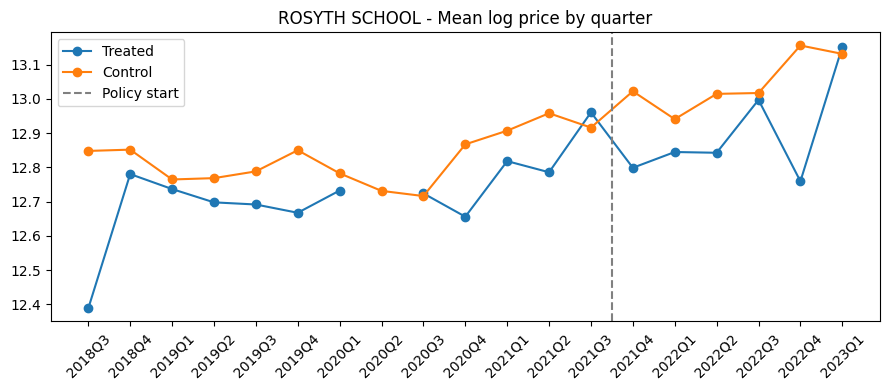


  Event-study coefficients relative to k = -1:
 event_time    coef  ci_low  ci_high
        -13 -0.0159 -0.0779   0.0462
        -12 -0.0260 -0.0998   0.0477
        -11  0.0219 -0.0049   0.0487
        -10  0.1071  0.0607   0.1534
         -9  0.0633  0.0306   0.0960
         -8 -0.0163 -0.1308   0.0983
         -7  0.1262  0.0292   0.2231
         -6 -0.0000 -0.0000  -0.0000
         -5 -0.0030 -0.0184   0.0124
         -4  0.0906 -0.0296   0.2109
         -3  0.0689  0.0437   0.0941
         -2  0.1044  0.0524   0.1563
         -1  0.0000  0.0000   0.0000
          0  0.0582 -0.0020   0.1185
          1  0.0660 -0.0112   0.1432
          2  0.1010  0.0268   0.1753
          3  0.0631  0.0121   0.1141
          4  0.0730  0.0614   0.0845
          5  0.0698  0.0134   0.1262

  Joint test of pre-treatment leads = 0: F = 85475399311393.2344, p-value = 0.0000
  Pre-trends pass: ❌
  Anticipation signal: ✅


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 6
  warnings.warn('covariance of constraints does not have full '


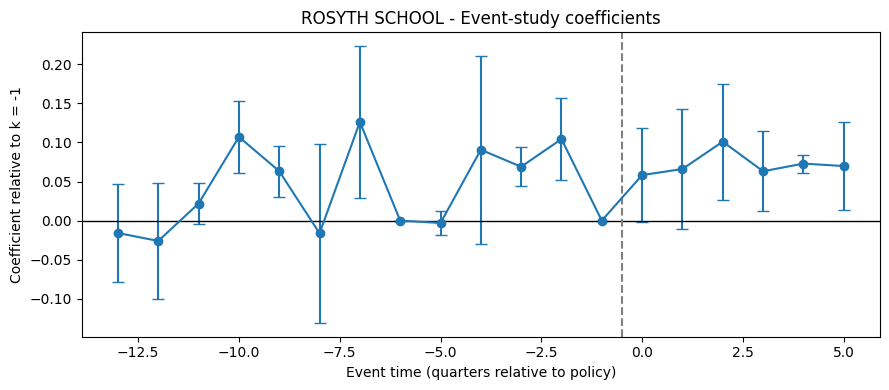


------------------------------------------------------------
Event Study: ST. HILDA'S PRIMARY SCHOOL
------------------------------------------------------------
  Final local sample: 845
  Treated obs: 47
  Control obs: 798

  Transaction counts:
 treated period   n
       0   post 288
       0    pre 510
       1   post  20
       1    pre  27
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']


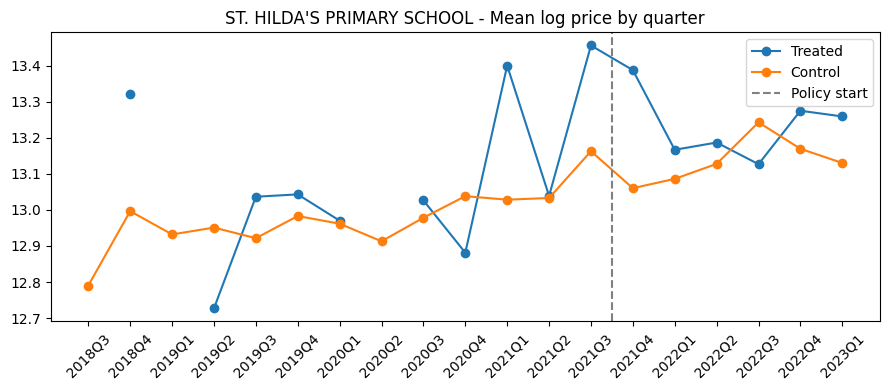


  Event-study coefficients relative to k = -1:
 event_time    coef  ci_low  ci_high
        -13 -0.0000 -0.0000  -0.0000
        -12 -0.0362 -0.0592  -0.0131
        -11 -0.0000 -0.0000   0.0000
        -10  0.0265 -0.0399   0.0928
         -9  0.1581  0.1288   0.1874
         -8  0.0976  0.0566   0.1385
         -7  0.0007 -0.1010   0.1025
         -6  0.0000  0.0000   0.0000
         -5  0.0309 -0.0253   0.0871
         -4  0.0238 -0.0307   0.0783
         -3  0.0030 -0.0267   0.0327
         -2  0.0819  0.0470   0.1168
         -1  0.0000  0.0000   0.0000
          0  0.1318  0.1116   0.1519
          1 -0.0288 -0.0870   0.0293
          2  0.0737  0.0319   0.1155
          3  0.0400  0.0038   0.0763
          4  0.0412 -0.0185   0.1008
          5  0.0935  0.0602   0.1267

  Joint test of pre-treatment leads = 0: F = -1222709462568.1211, p-value = 1.0000
  Pre-trends pass: ✅
  Anticipation signal: ❌


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 4
  warnings.warn('covariance of constraints does not have full '


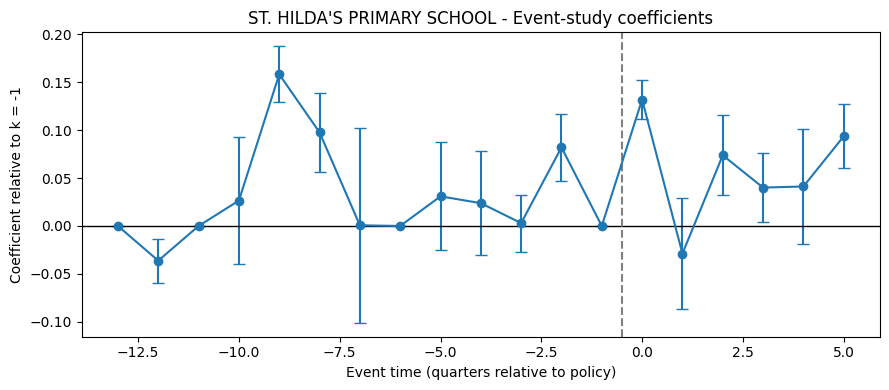


------------------------------------------------------------
Event Study: PEI CHUN PUBLIC SCHOOL
------------------------------------------------------------
  Final local sample: 883
  Treated obs: 36
  Control obs: 847

  Transaction counts:
 treated period   n
       0   post 410
       0    pre 437
       1   post   7
       1    pre  29
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']


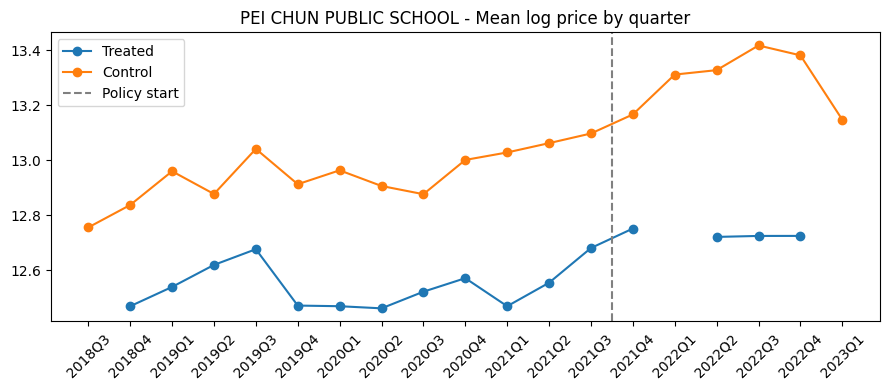


  Event-study coefficients relative to k = -1:
 event_time    coef  ci_low  ci_high
        -13 -0.0000 -0.0000  -0.0000
        -12 -0.0525 -0.1070   0.0021
        -11 -0.0478 -0.1099   0.0143
        -10  0.0091 -0.0376   0.0557
         -9 -0.0612 -0.1399   0.0175
         -8 -0.0615 -0.0832  -0.0398
         -7 -0.0707 -0.1338  -0.0075
         -6 -0.0393 -0.0809   0.0024
         -5 -0.0300 -0.0674   0.0074
         -4 -0.0304 -0.0474  -0.0135
         -3 -0.1231 -0.1670  -0.0792
         -2 -0.0341 -0.0442  -0.0240
         -1  0.0000  0.0000   0.0000
          0  0.0918  0.0700   0.1135
          1  0.0000  0.0000   0.0000
          2  0.0264  0.0111   0.0418
          3 -0.0017 -0.0089   0.0055
          4  0.0158 -0.0058   0.0375
          5  0.0000  0.0000   0.0000

  Joint test of pre-treatment leads = 0: F = 4.2532, p-value = 0.1904
  Pre-trends pass: ✅
  Anticipation signal: ❌


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 2
  warnings.warn('covariance of constraints does not have full '


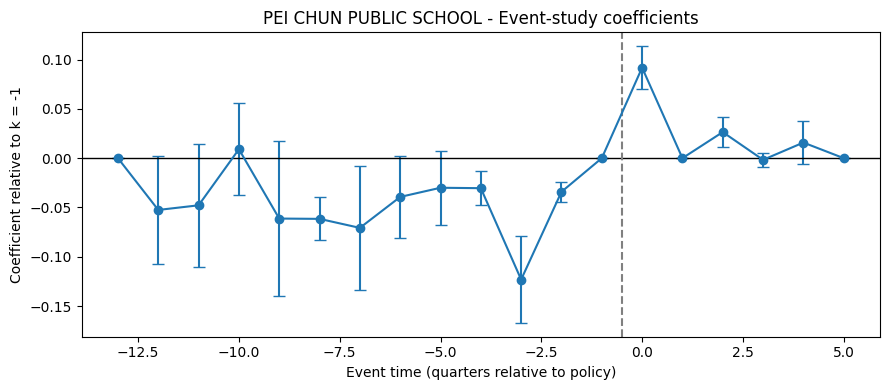


------------------------------------------------------------
Event Study: RULANG PRIMARY SCHOOL
------------------------------------------------------------
  Final local sample: 878
  Treated obs: 115
  Control obs: 763

  Transaction counts:
 treated period   n
       0   post 258
       0    pre 505
       1   post  44
       1    pre  71
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']


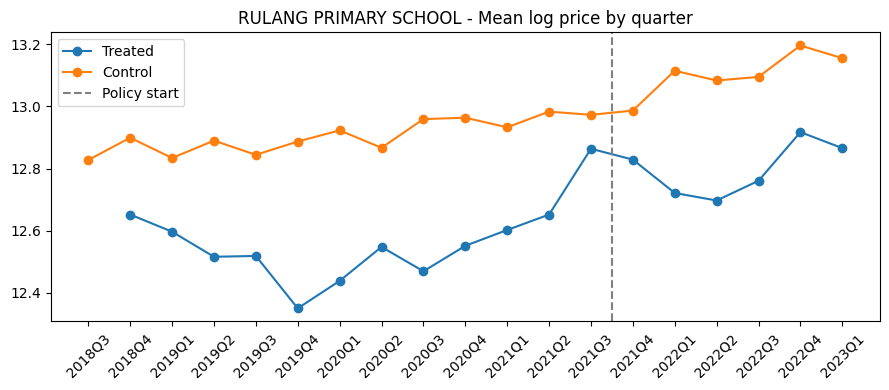


  Event-study coefficients relative to k = -1:
 event_time    coef  ci_low  ci_high
        -13 -0.0000 -0.0000  -0.0000
        -12 -0.0430 -0.1112   0.0251
        -11 -0.0421 -0.0871   0.0028
        -10 -0.0093 -0.0442   0.0256
         -9 -0.0448 -0.0552  -0.0345
         -8 -0.0870 -0.1281  -0.0459
         -7 -0.1128 -0.1619  -0.0637
         -6 -0.0956 -0.1784  -0.0128
         -5 -0.0923 -0.1336  -0.0511
         -4 -0.0670 -0.1340   0.0001
         -3 -0.0238 -0.0547   0.0072
         -2  0.0002 -0.0542   0.0546
         -1  0.0000  0.0000   0.0000
          0 -0.0278 -0.1122   0.0566
          1 -0.0127 -0.0650   0.0396
          2  0.0030 -0.0341   0.0401
          3  0.0189 -0.0234   0.0613
          4  0.0256 -0.0296   0.0807
          5 -0.0125 -0.1003   0.0754

  Joint test of pre-treatment leads = 0: F = -10451585267233.2930, p-value = 1.0000
  Pre-trends pass: ✅
  Anticipation signal: ❌


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 5
  warnings.warn('covariance of constraints does not have full '


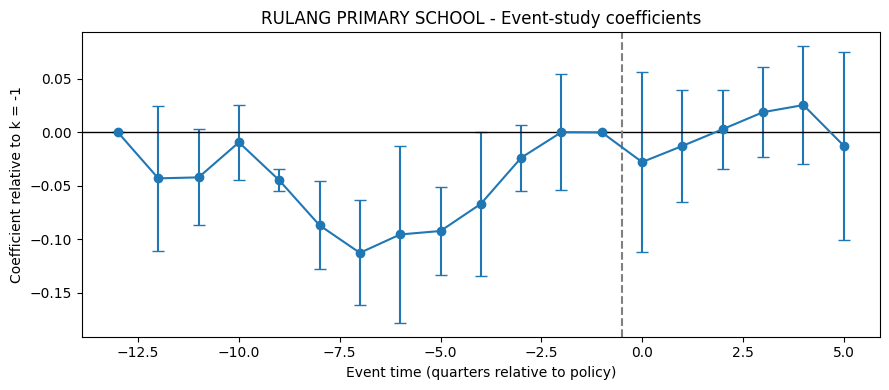


------------------------------------------------------------
Event Study: FAIRFIELD METHODIST SCHOOL (PRIMARY)
------------------------------------------------------------
  Final local sample: 1499
  Treated obs: 67
  Control obs: 1432

  Transaction counts:
 treated period   n
       0   post 465
       0    pre 967
       1   post  30
       1    pre  37
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']


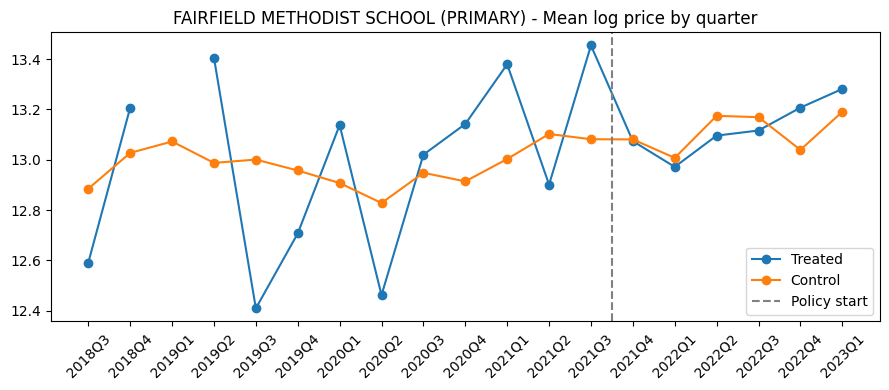


  Event-study coefficients relative to k = -1:
 event_time    coef  ci_low  ci_high
        -13 -0.2038 -0.3695  -0.0381
        -12  0.0401 -0.0645   0.1448
        -11  0.0000 -0.0000   0.0000
        -10  0.0647 -0.0335   0.1628
         -9 -0.0094 -0.1618   0.1430
         -8 -0.0819 -0.1891   0.0253
         -7  0.0249 -0.0481   0.0978
         -6 -0.1452 -0.2485  -0.0419
         -5  0.0341 -0.1238   0.1919
         -4 -0.0049 -0.1012   0.0914
         -3  0.0847 -0.0014   0.1708
         -2 -0.0910 -0.1453  -0.0367
         -1  0.0000  0.0000   0.0000
          0 -0.0462 -0.2017   0.1093
          1 -0.0581 -0.1617   0.0455
          2 -0.0076 -0.1126   0.0973
          3  0.0094 -0.0904   0.1092
          4 -0.0244 -0.2006   0.1519
          5 -0.0083 -0.1027   0.0861

  Joint test of pre-treatment leads = 0: F = -26967816250217.7578, p-value = 1.0000
  Pre-trends pass: ✅
  Anticipation signal: ❌


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 4
  warnings.warn('covariance of constraints does not have full '


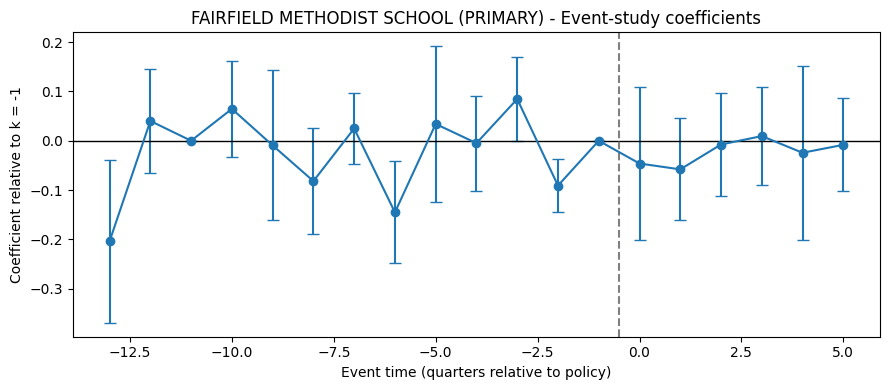


------------------------------------------------------------
Event Study: CHONGFU SCHOOL
------------------------------------------------------------
  Final local sample: 855
  Treated obs: 182
  Control obs: 673

  Transaction counts:
 treated period   n
       0   post 287
       0    pre 386
       1   post  90
       1    pre  92
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']


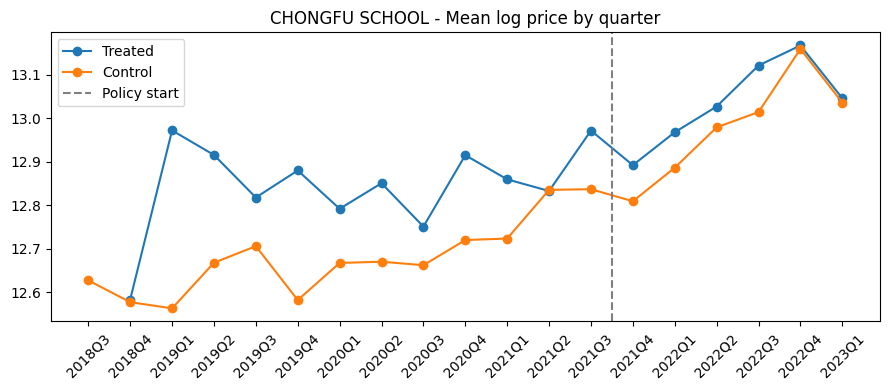


  Event-study coefficients relative to k = -1:
 event_time    coef  ci_low  ci_high
        -13 -0.0000 -0.0000  -0.0000
        -12  0.0389 -0.0238   0.1015
        -11  0.1693  0.0907   0.2480
        -10  0.1013  0.0460   0.1566
         -9  0.0863  0.0238   0.1488
         -8  0.0982  0.0069   0.1894
         -7  0.0319 -0.0125   0.0763
         -6  0.0367  0.0209   0.0525
         -5  0.0487 -0.0265   0.1239
         -4  0.0357 -0.0187   0.0902
         -3  0.0439  0.0032   0.0846
         -2  0.0166 -0.0190   0.0522
         -1  0.0000  0.0000   0.0000
          0  0.0286 -0.0214   0.0787
          1  0.0464 -0.0090   0.1018
          2  0.0628 -0.0002   0.1257
          3  0.0472  0.0060   0.0885
          4  0.0207 -0.0586   0.0999
          5  0.0411 -0.0031   0.0854

  Joint test of pre-treatment leads = 0: F = -107581204821520.2656, p-value = 1.0000
  Pre-trends pass: ✅
  Anticipation signal: ❌


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 4
  warnings.warn('covariance of constraints does not have full '


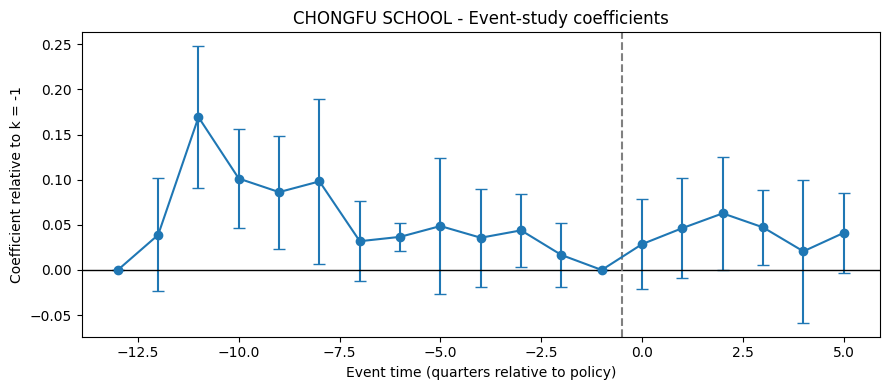


------------------------------------------------------------
Event Study: CHIJ PRIMARY (TOA PAYOH)
------------------------------------------------------------
  Final local sample: 359
  Treated obs: 19
  Control obs: 340

  Transaction counts:
 treated period   n
       0   post 172
       0    pre 168
       1   post   9
       1    pre  10
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']


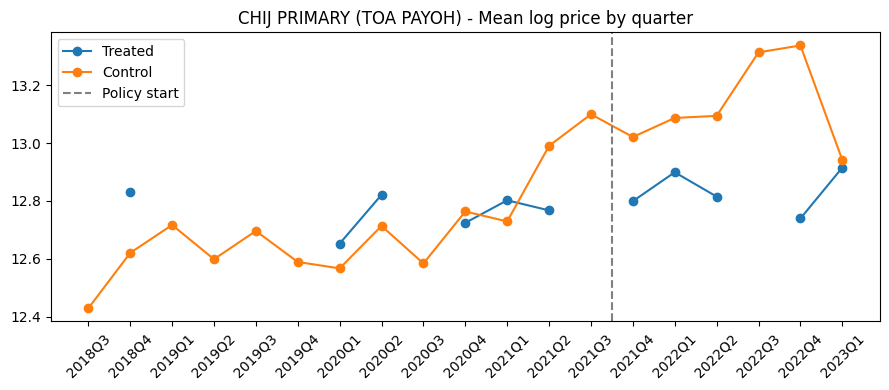


  Event-study coefficients relative to k = -1:
 event_time    coef  ci_low  ci_high
        -13  0.0000  0.0000   0.0000
        -12  0.0513  0.0314   0.0712
        -11 -0.0000 -0.0000  -0.0000
        -10  0.0000 -0.0000   0.0000
         -9  0.0000 -0.0000   0.0000
         -8  0.0000 -0.0000   0.0000
         -7  0.0398 -0.0040   0.0837
         -6  0.0329 -0.0370   0.1028
         -5  0.0000  0.0000   0.0000
         -4 -0.0712 -0.1089  -0.0334
         -3 -0.0701 -0.1085  -0.0317
         -2  0.0614  0.0302   0.0926
         -1  0.0000  0.0000   0.0000
          0  0.0579  0.0348   0.0809
          1  0.0240 -0.0132   0.0613
          2  0.0005 -0.0425   0.0435
          3  0.0000  0.0000   0.0000
          4  0.0142 -0.0130   0.0413
          5 -0.0565 -0.0840  -0.0291

  Joint test of pre-treatment leads = 0: F = 7.7492, p-value = 0.1143
  Pre-trends pass: ✅
  Anticipation signal: ❌


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 2
  warnings.warn('covariance of constraints does not have full '


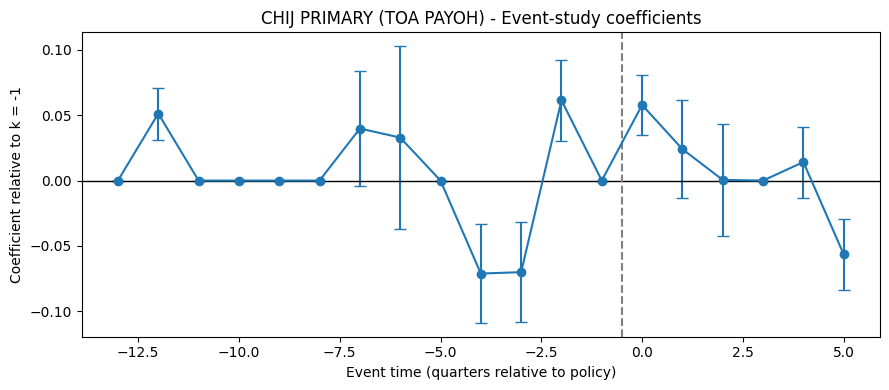


------------------------------------------------------------
Event Study: MAHA BODHI SCHOOL
------------------------------------------------------------
  Final local sample: 1200
  Treated obs: 92
  Control obs: 1108

  Transaction counts:
 treated period   n
       0   post 431
       0    pre 677
       1   post  41
       1    pre  51
  Dropping low-variation covariates: []
  Keeping numeric covariates: ['floor_area_sqm', 'remaining_lease']
  Keeping categorical covariates: ['flat_model', 'storey_range']


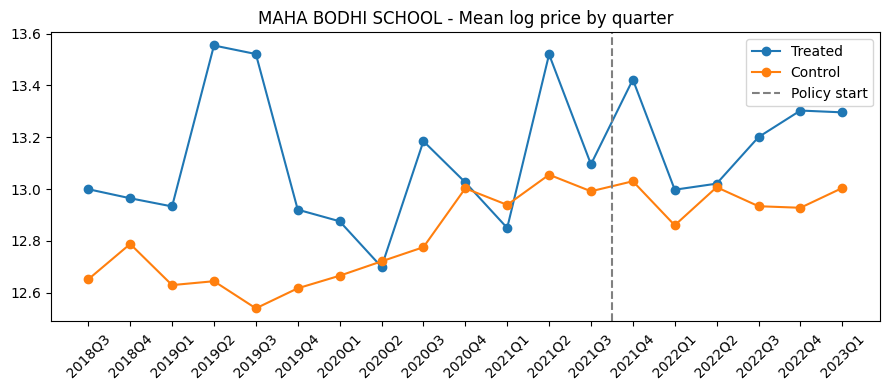


  Event-study coefficients relative to k = -1:
 event_time    coef  ci_low  ci_high
        -13 -0.2146 -0.3521  -0.0771
        -12 -0.0864 -0.2188   0.0461
        -11 -0.2697 -0.3635  -0.1759
        -10  0.1404 -0.1686   0.4494
         -9  0.3240  0.1851   0.4630
         -8 -0.1827 -0.3167  -0.0487
         -7 -0.1111 -0.2351   0.0130
         -6 -0.0907 -0.2636   0.0822
         -5 -0.0279 -0.2430   0.1872
         -4 -0.0909 -0.2592   0.0775
         -3 -0.1704 -0.3097  -0.0310
         -2  0.0626 -0.0767   0.2018
         -1  0.0000  0.0000   0.0000
          0  0.0711  0.0150   0.1273
          1 -0.1545 -0.2605  -0.0485
          2 -0.1778 -0.3125  -0.0431
          3 -0.1091 -0.1800  -0.0382
          4 -0.0193 -0.1027   0.0641
          5 -0.0702 -0.1305  -0.0099

  Joint test of pre-treatment leads = 0: F = 5.2324, p-value = 0.0690
  Pre-trends pass: ✅
  Anticipation signal: ❌


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 4
  warnings.warn('covariance of constraints does not have full '


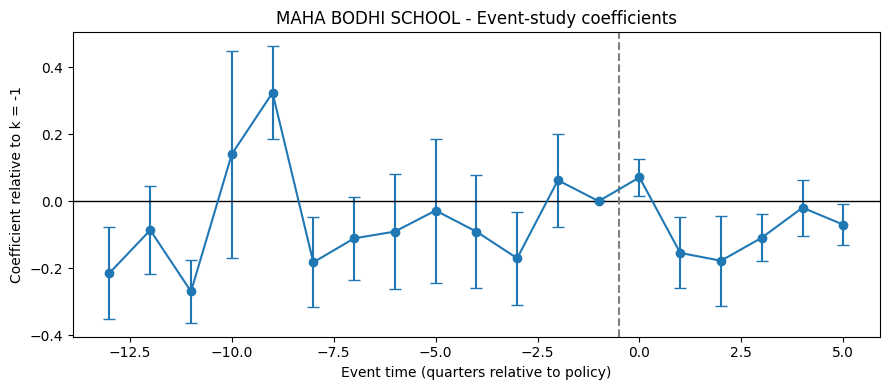


EVENT-STUDY SUMMARY
                         school_name  n_obs  n_treated_pre  n_treated_post  n_control_pre  n_control_post  n_pre_leads  n_post_lags        lead_f  lead_p pretrend_pass anticipation_signal
                       ROSYTH SCHOOL    779             35              26            480             238           12            6  8.547540e+13  0.0000             ❌                   ✅
          ST. HILDA'S PRIMARY SCHOOL    845             27              20            510             288           12            6 -1.222709e+12  1.0000             ✅                   ❌
              PEI CHUN PUBLIC SCHOOL    883             29               7            437             410           12            6  4.253200e+00  0.1904             ✅                   ❌
               RULANG PRIMARY SCHOOL    878             71              44            505             258           12            6 -1.045159e+13  1.0000             ✅                   ❌
FAIRFIELD METHODIST SCHOOL (PRIMARY)   

In [14]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

print("\n" + "="*70)
print("STANDARD EVENT-STUDY ANTICIPATION TEST (PASSED SCHOOLS)")
print("="*70)


def has_focal_school(name_cell, school_name):
    if pd.isna(name_cell):
        return False
    schools = [s.strip().upper() for s in str(name_cell).split('|') if s.strip()]
    return school_name.strip().upper() in schools


passed_schools = results_df.loc[
    results_df['paralleltrend_result'] == '\u2705', 'school_name'
].tolist()

print(f"Schools passing pre-trends: {len(passed_schools)}")

event_study_results = []

for school_name in passed_schools:
    school_name = school_name.strip().upper()

    print(f"\n{'-'*60}")
    print(f"Event Study: {school_name}")
    print(f"{'-'*60}")

    # -----------------------------------------------------------------------
    # 1. Rebuild the exact DID sample using the original specifications
    # -----------------------------------------------------------------------
    school_match = good_school_poly_gdf[
        good_school_poly_gdf['school_name'].str.strip().str.upper() == school_name
    ]
    if school_match.empty:
        print("  Skipping: school not found in polygons.")
        continue

    school = school_match.iloc[0]
    school_geom = school['geometry']
    buffer_2km = school_geom.buffer(2000)
    hdb_local = resale_gdf[resale_gdf.geometry.within(buffer_2km)].copy()

    if hdb_local.empty:
        print("  Skipping: no transactions within 2km.")
        continue

    hdb_local = hdb_local[
        ((hdb_local['Date'] >= pre_start) & (hdb_local['Date'] <= pre_end)) |
        ((hdb_local['Date'] >= post_start) & (hdb_local['Date'] <= post_end))
    ].copy()

    if hdb_local.empty:
        print("  Skipping: no transactions in sample window.")
        continue

    hdb_local['post'] = (hdb_local['Date'] >= post_start).astype(int)

    hdb_local['pre_in_1km_focal'] = hdb_local['good_school_names_0_1km_xy'].apply(
        lambda x: has_focal_school(x, school_name)
    ).astype(int)
    hdb_local['post_in_1km_focal'] = hdb_local['good_school_names_0_1km_polygon'].apply(
        lambda x: has_focal_school(x, school_name)
    ).astype(int)

    did_local = hdb_local[hdb_local['pre_in_1km_focal'] == 0].copy()

    did_local['treated'] = (
        (did_local['pre_in_1km_focal'] == 0) &
        (did_local['post_in_1km_focal'] == 1)
    ).astype(int)

    did_local = did_local[
        ((did_local['treated'] == 1) & (did_local['post_in_1km_focal'] == 1)) |
        ((did_local['treated'] == 0) & (did_local['post_in_1km_focal'] == 0))
    ].copy()

    # -----------------------------------------------------------------------
    # 2. Composition restrictions from the initial DID setup
    # -----------------------------------------------------------------------
    did_local['pre_num_good_schools_0_1km'] = did_local['num_good_schools_0_1km_xy']
    did_local['post_num_good_schools_0_1km'] = did_local['num_good_schools_0_1km_polygon']
    did_local['pre_num_good_schools_1_2km'] = did_local['num_good_schools_1_2km_xy']
    did_local['post_num_good_schools_1_2km'] = did_local['num_good_schools_1_2km_polygon']

    did_local['pre_num_schools_0_1km'] = did_local['num_schools_0_1km_xy']
    did_local['post_num_schools_0_1km'] = did_local['num_schools_0_1km_polygon']
    did_local['pre_num_schools_1_2km'] = did_local['num_schools_1_2km_xy']
    did_local['post_num_schools_1_2km'] = did_local['num_schools_1_2km_polygon']

    did_local['pre_num_normal_schools_0_1km'] = (
        did_local['pre_num_schools_0_1km'] - did_local['pre_num_good_schools_0_1km']
    )
    did_local['post_num_normal_schools_0_1km'] = (
        did_local['post_num_schools_0_1km'] - did_local['post_num_good_schools_0_1km']
    )
    did_local['pre_num_normal_schools_1_2km'] = (
        did_local['pre_num_schools_1_2km'] - did_local['pre_num_good_schools_1_2km']
    )
    did_local['post_num_normal_schools_1_2km'] = (
        did_local['post_num_schools_1_2km'] - did_local['post_num_good_schools_1_2km']
    )

    did_local = did_local[
        (did_local['pre_num_normal_schools_0_1km'] == did_local['post_num_normal_schools_0_1km']) &
        (did_local['pre_num_normal_schools_1_2km'] == did_local['post_num_normal_schools_1_2km'])
    ].copy()

    did_local = did_local[
        ((did_local['treated'] == 1) & (did_local['post_num_good_schools_0_1km'] == 1)) |
        ((did_local['treated'] == 0) & (did_local['post_num_good_schools_0_1km'] == 0))
    ].copy()

    # -----------------------------------------------------------------------
    # 3. Final regression variables from the original DID setup
    # -----------------------------------------------------------------------
    did_local['year_month'] = did_local['Date'].dt.to_period('M').astype(str)
    did_local['year_quarter_period'] = did_local['Date'].dt.to_period('Q')
    did_local['year_quarter'] = did_local['year_quarter_period'].astype(str)
    did_local['period'] = np.where(did_local['Date'] >= post_start, 'post', 'pre')
    did_local['log_price'] = np.log(did_local['resale_price'])

    print(f"  Final local sample: {len(did_local)}")
    print(f"  Treated obs: {(did_local['treated'] == 1).sum()}")
    print(f"  Control obs: {(did_local['treated'] == 0).sum()}")

    if did_local.empty or did_local['treated'].nunique() < 2:
        print("  Skipping: no treated-control variation after filtering.")
        continue

    did_tight = did_local.copy()

    counts = did_tight.groupby(['treated', 'period']).size().reset_index(name='n')
    print("\n  Transaction counts:")
    print(counts.to_string(index=False))

    treated_pre = did_tight[(did_tight['treated'] == 1) & (did_tight['period'] == 'pre')]
    treated_post = did_tight[(did_tight['treated'] == 1) & (did_tight['period'] == 'post')]
    control_pre = did_tight[(did_tight['treated'] == 0) & (did_tight['period'] == 'pre')]
    control_post = did_tight[(did_tight['treated'] == 0) & (did_tight['period'] == 'post')]

    did_tight['unit_group'] = did_tight['flat_type'].astype(str)

    numeric_covariates = [
        'floor_area_sqm',
        'remaining_lease',
    ]
    categorical_covariates = ['flat_model', 'storey_range']

    active_numeric_covariates = [
        col for col in numeric_covariates
        if did_tight[col].nunique(dropna=True) > 1
    ]
    active_categorical_covariates = [
        col for col in categorical_covariates
        if did_tight[col].nunique(dropna=True) > 1
    ]
    dropped_covariates = [
        col for col in numeric_covariates + categorical_covariates
        if col not in active_numeric_covariates + active_categorical_covariates
    ]

    print(f"  Dropping low-variation covariates: {dropped_covariates}")
    print(f"  Keeping numeric covariates: {active_numeric_covariates}")
    print(f"  Keeping categorical covariates: {active_categorical_covariates}")

    covariate_terms = active_numeric_covariates + [f"C({col})" for col in active_categorical_covariates]
    covariate_formula = f"+ {' + '.join(covariate_terms)}" if covariate_terms else ''

    # -----------------------------------------------------------------------
    # 4. Standard event study on the exact DID sample
    # -----------------------------------------------------------------------
    policy_q = pd.Period(post_start, freq='Q')
    did_tight['event_time'] = (
        did_tight['year_quarter_period'] - policy_q
    ).apply(lambda x: x.n).astype(int)
    did_tight['event_time_str'] = did_tight['event_time'].astype(str)

    if -1 not in did_tight['event_time'].unique():
        print("  Skipping: missing baseline quarter k=-1.")
        continue

    pre_leads = sorted(k for k in did_tight['event_time'].unique() if k < -1)
    post_lags = sorted(k for k in did_tight['event_time'].unique() if k >= 0)

    if not pre_leads:
        print("  Skipping: no pre-treatment leads available.")
        continue

    ts = (
        did_tight
        .groupby(['year_quarter_period', 'treated'])['log_price']
        .mean()
        .reset_index()
    )
    pivot_ts = ts.pivot(index='year_quarter_period', columns='treated', values='log_price').sort_index()

    if {0, 1}.issubset(set(pivot_ts.columns)):
        x_pos = np.arange(len(pivot_ts.index))
        labels = pivot_ts.index.astype(str)

        plt.figure(figsize=(9, 4))
        plt.plot(x_pos, pivot_ts[1], label='Treated', marker='o')
        plt.plot(x_pos, pivot_ts[0], label='Control', marker='o')

        if policy_q in pivot_ts.index:
            policy_pos = list(pivot_ts.index).index(policy_q) - 0.5
            plt.axvline(policy_pos, color='gray', linestyle='--', label='Policy start')

        plt.xticks(x_pos, labels, rotation=45)
        plt.title(f"{school_name} - Mean log price by quarter")
        plt.legend()
        plt.tight_layout()
        plt.show()

    baseline_quarter = str(policy_q - 1)

    formula = f"""
        log_price ~ treated
        + C(year_quarter, Treatment(reference='{baseline_quarter}'))
        + treated:C(event_time_str, Treatment(reference='-1'))
        {covariate_formula}
        + C(unit_group)
    """

    try:
        es_model = smf.ols(formula, data=did_tight).fit(
            cov_type='cluster',
            cov_kwds={'groups': did_tight['unit_group']}
        )
    except Exception as e:
        print(f"  Event study failed: {e}")
        continue

    coef_rows = [{
        'event_time': -1,
        'coef': 0.0,
        'ci_low': 0.0,
        'ci_high': 0.0,
    }]
    lead_terms = []

    for term in es_model.params.index:
        if 'event_time_str' not in term or 'treated' not in term:
            continue

        match = re.search(r'\[T\.(-?\d+)\]', term)
        if match is None:
            continue

        k = int(match.group(1))
        coef = es_model.params[term]
        se = es_model.bse[term]

        coef_rows.append({
            'event_time': k,
            'coef': coef,
            'ci_low': coef - 1.96 * se,
            'ci_high': coef + 1.96 * se,
        })

        if k < 0:
            lead_terms.append((k, term))

    coef_df = pd.DataFrame(coef_rows).sort_values('event_time').reset_index(drop=True)

    print("\n  Event-study coefficients relative to k = -1:")
    print(coef_df.round(4).to_string(index=False))

    lead_f = np.nan
    lead_p = np.nan
    pretrend_result = 'N/A'
    anticipation_signal = 'N/A'

    estimable_pre_terms = [term for k, term in lead_terms if k < -1]
    if estimable_pre_terms:
        R = np.zeros((len(estimable_pre_terms), len(es_model.params)))
        for i, term in enumerate(estimable_pre_terms):
            R[i, es_model.params.index.get_loc(term)] = 1.0

        lead_test = es_model.f_test(R)
        lead_f = float(np.asarray(lead_test.fvalue).squeeze())
        lead_p = float(np.asarray(lead_test.pvalue).squeeze())
        pretrend_result = '\u2705' if lead_p > 0.05 else '\u274c'
        anticipation_signal = '\u2705' if lead_p <= 0.05 else '\u274c'

        print(
            f"\n  Joint test of pre-treatment leads = 0: "
            f"F = {lead_f:.4f}, p-value = {lead_p:.4f}"
        )
        print(f"  Pre-trends pass: {pretrend_result}")
        print(f"  Anticipation signal: {anticipation_signal}")
    else:
        print("\n  Joint test skipped: no estimable pre-treatment leads beyond k = -1.")

    plt.figure(figsize=(9, 4))
    plt.errorbar(
        coef_df['event_time'],
        coef_df['coef'],
        yerr=[
            coef_df['coef'] - coef_df['ci_low'],
            coef_df['ci_high'] - coef_df['coef'],
        ],
        fmt='o-',
        capsize=4,
    )
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(-0.5, color='gray', linestyle='--', label='Policy start')
    plt.title(f"{school_name} - Event-study coefficients")
    plt.xlabel("Event time (quarters relative to policy)")
    plt.ylabel("Coefficient relative to k = -1")
    plt.tight_layout()
    plt.show()

    event_study_results.append({
        'school_name': school_name,
        'n_obs': len(did_tight),
        'n_treated_pre': len(treated_pre),
        'n_treated_post': len(treated_post),
        'n_control_pre': len(control_pre),
        'n_control_post': len(control_post),
        'n_pre_leads': len(pre_leads),
        'n_post_lags': len(post_lags),
        'lead_f': lead_f,
        'lead_p': lead_p,
        'pretrend_pass': pretrend_result,
        'anticipation_signal': anticipation_signal,
    })

summary_df = pd.DataFrame(event_study_results)

if not summary_df.empty:
    for col in ['lead_f', 'lead_p']:
        summary_df[col] = summary_df[col].round(4)

    print("\n" + "="*70)
    print("EVENT-STUDY SUMMARY")
    print("="*70)
    print(summary_df.to_string(index=False))


In [15]:
summary_df[
    ['school_name', 'n_treated_pre', 'n_treated_post', 'n_control_pre', 'n_control_post', 'lead_p']
]

,school_name,n_treated_pre,n_treated_post,n_control_pre,n_control_post,lead_p
0,ROSYTH SCHOOL,35,26,480,238,0.0000
1,ST. HILDA'S PRIMARY SCHOOL,27,20,510,288,1.0000
2,PEI CHUN PUBLIC SCHOOL,29,7,437,410,0.1904
3,RULANG PRIMARY SCHOOL,71,44,505,258,1.0000
4,FAIRFIELD METHODIST SCHOOL (PRIMARY),37,30,967,465,1.0000
5,CHONGFU SCHOOL,92,90,386,287,1.0000
6,CHIJ PRIMARY (TOA PAYOH),10,9,168,172,0.1143
7,MAHA BODHI SCHOOL,51,41,677,431,0.0690
